# EDA

## Категории товаров

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

os.chdir('..')

In [2]:
os.listdir("data/raw")

['items.csv',
 'item_categories.csv',
 'sales_train.csv',
 'sample_submission.csv',
 'shops.csv',
 'test.csv']

In [223]:
item_categories = pd.read_csv('data/raw/item_categories.csv')
item_categories.head()

,item_category_name,item_category_id
0,PC - Гарнитуры/Наушники,0
1,Аксессуары - PS2,1
2,Аксессуары - PS3,2
3,Аксессуары - PS4,3
4,Аксессуары - PSP,4


In [224]:
item_categories.shape

(84, 2)

In [225]:
item_categories.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   item_category_name  84 non-null     str  
 1   item_category_id    84 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1.4 KB


In [226]:
# дубликаты

item_categories.duplicated().sum()

np.int64(0)

In [227]:
# isna

item_categories.isna().sum()

item_category_name    0
item_category_id      0
dtype: int64

In [228]:
# уникальность

item_categories.nunique()

item_category_name    84
item_category_id      84
dtype: int64

In [229]:
print([x for x in item_categories['item_category_name']])

['PC - Гарнитуры/Наушники', 'Аксессуары - PS2', 'Аксессуары - PS3', 'Аксессуары - PS4', 'Аксессуары - PSP', 'Аксессуары - PSVita', 'Аксессуары - XBOX 360', 'Аксессуары - XBOX ONE', 'Билеты (Цифра)', 'Доставка товара', 'Игровые консоли - PS2', 'Игровые консоли - PS3', 'Игровые консоли - PS4', 'Игровые консоли - PSP', 'Игровые консоли - PSVita', 'Игровые консоли - XBOX 360', 'Игровые консоли - XBOX ONE', 'Игровые консоли - Прочие', 'Игры - PS2', 'Игры - PS3', 'Игры - PS4', 'Игры - PSP', 'Игры - PSVita', 'Игры - XBOX 360', 'Игры - XBOX ONE', 'Игры - Аксессуары для игр', 'Игры Android - Цифра', 'Игры MAC - Цифра', 'Игры PC - Дополнительные издания', 'Игры PC - Коллекционные издания', 'Игры PC - Стандартные издания', 'Игры PC - Цифра', 'Карты оплаты (Кино, Музыка, Игры)', 'Карты оплаты - Live!', 'Карты оплаты - Live! (Цифра)', 'Карты оплаты - PSN', 'Карты оплаты - Windows (Цифра)', 'Кино - Blu-Ray', 'Кино - Blu-Ray 3D', 'Кино - Blu-Ray 4K', 'Кино - DVD', 'Кино - Коллекционное', 'Книги - Арт

In [230]:
# Укрупнение категорий

item_categories["main_category"] = (
    item_categories["item_category_name"]
    .str.split(" - ")
    .str[0]
)

item_categories[[
    "item_category_name",
    "main_category"
]].head()

,item_category_name,main_category
0,PC - Гарнитуры/Наушники,PC
1,Аксессуары - PS2,Аксессуары
2,Аксессуары - PS3,Аксессуары
3,Аксессуары - PS4,Аксессуары
4,Аксессуары - PSP,Аксессуары


In [231]:
item_categories["main_category"].value_counts()

main_category
Книги                                13
Подарки                              12
Игровые консоли                       8
Игры                                  8
Аксессуары                            7
Музыка                                6
Программы                             6
Кино                                  5
Игры PC                               4
Карты оплаты                          4
Служебные                             2
PC                                    1
Билеты (Цифра)                        1
Доставка товара                       1
Игры Android                          1
Игры MAC                              1
Карты оплаты (Кино, Музыка, Игры)     1
Чистые носители (шпиль)               1
Чистые носители (штучные)             1
Элементы питания                      1
Name: count, dtype: int64

In [232]:
import textwrap


def make_count_barplot(data: pd.DataFrame, groupby: str, aggregate: str, title: str, xlabel: str, ylabel: str, 
                       file_name: str, annotation: bool, top_n: int):
    
    if top_n == 0:
        top_n = data[groupby].nunique()

    grouped_data = data.groupby(groupby)[aggregate].nunique().reset_index().sort_values(aggregate, ascending=False)[:top_n]
    sorted_order = data.groupby(groupby)[aggregate].nunique().sort_values(ascending=False).index[:top_n]
    
    labels = list(grouped_data[groupby])
    labels = [str(x) for x in labels]
    wrapped_labels = [textwrap.fill(label, width=15) for label in labels]

    fig, ax = plt.subplots(figsize=(15, 12))
    sns.set_style("whitegrid")  
    sns.barplot(
        data=grouped_data,
        x=groupby,
        y=aggregate,
        hue=groupby,
        palette='tab20',
        ax=ax,
        order=sorted_order,
        legend=False
    )

    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.xticks(rotation=45, fontsize=10)

    if annotation == True: # аннотации
        for container in ax.containers:
            ax.bar_label(container, fmt='%d', fontsize=9, padding=2)

    plt.xticks(ticks=range(len(wrapped_labels)), labels=wrapped_labels, rotation=60, fontsize=10)
    plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.savefig(f"artifacts/figures/eda/{file_name}.png", dpi=300, bbox_inches='tight')
    plt.show()

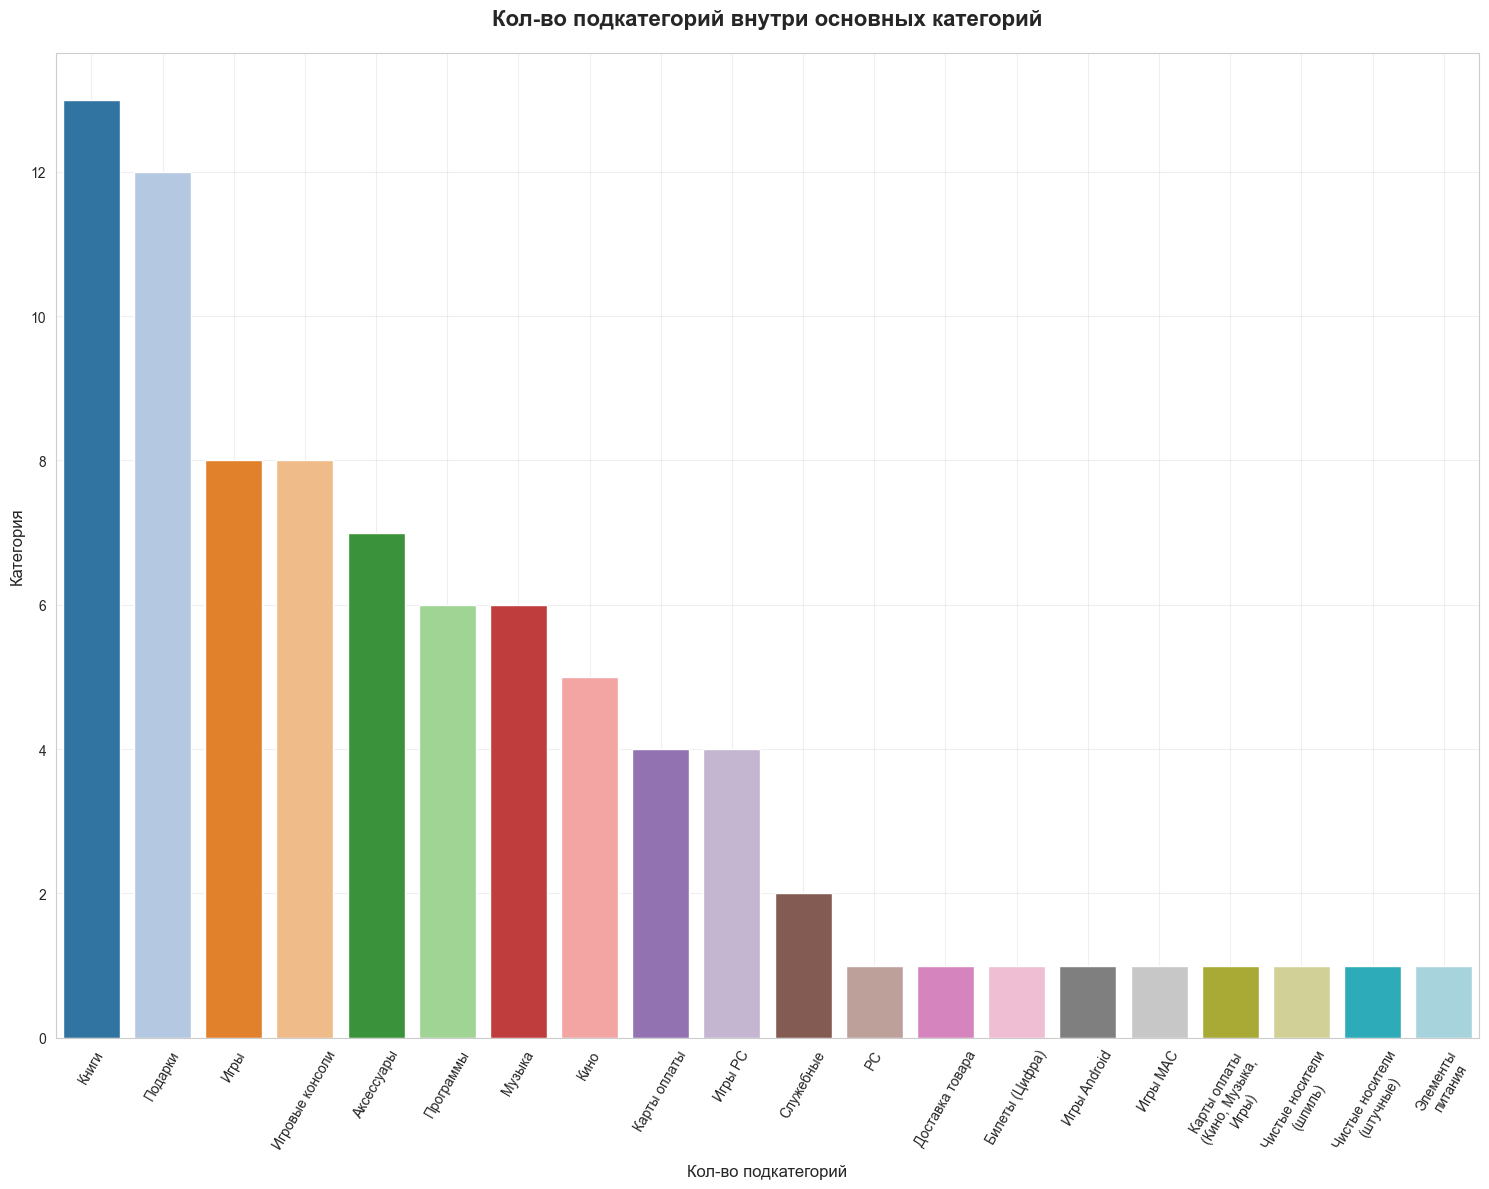

In [233]:
make_count_barplot(data=item_categories, groupby="main_category", aggregate="item_category_id", 
                   title="Кол-во подкатегорий внутри основных категорий", 
                   xlabel="Кол-во подкатегорий", ylabel="Категория", 
                   file_name= "subcategories_in_main_category", annotation=False,
                   top_n=0)

In [234]:
# Супер категории

def get_super_category(category):
    
    if category.startswith("Игры"):
        return "Игры"

    elif category.startswith("Игровые консоли"):
        return "Консоли"

    elif category.startswith("Аксессуары"):
        return "Аксессуары"

    elif category.startswith("Книги"):
        return "Книги"

    elif category.startswith("Музыка"):
        return "Музыка"

    elif category.startswith("Кино"):
        return "Кино"

    elif category.startswith("Подарки"):
        return "Подарки"

    elif category.startswith("Программы"):
        return "Программы"

    elif category.startswith("Карты оплаты"):
        return "Карты оплаты"

    elif category.startswith("Чистые носители"):
        return "Чистые носители"

    else:
        return "Прочее"
    
item_categories["super_category"] = (
    item_categories["item_category_name"]
    .apply(get_super_category)
)

item_categories["super_category"].value_counts()

super_category
Игры               14
Книги              13
Подарки            12
Консоли             8
Аксессуары          7
Прочее              6
Музыка              6
Программы           6
Карты оплаты        5
Кино                5
Чистые носители     2
Name: count, dtype: int64

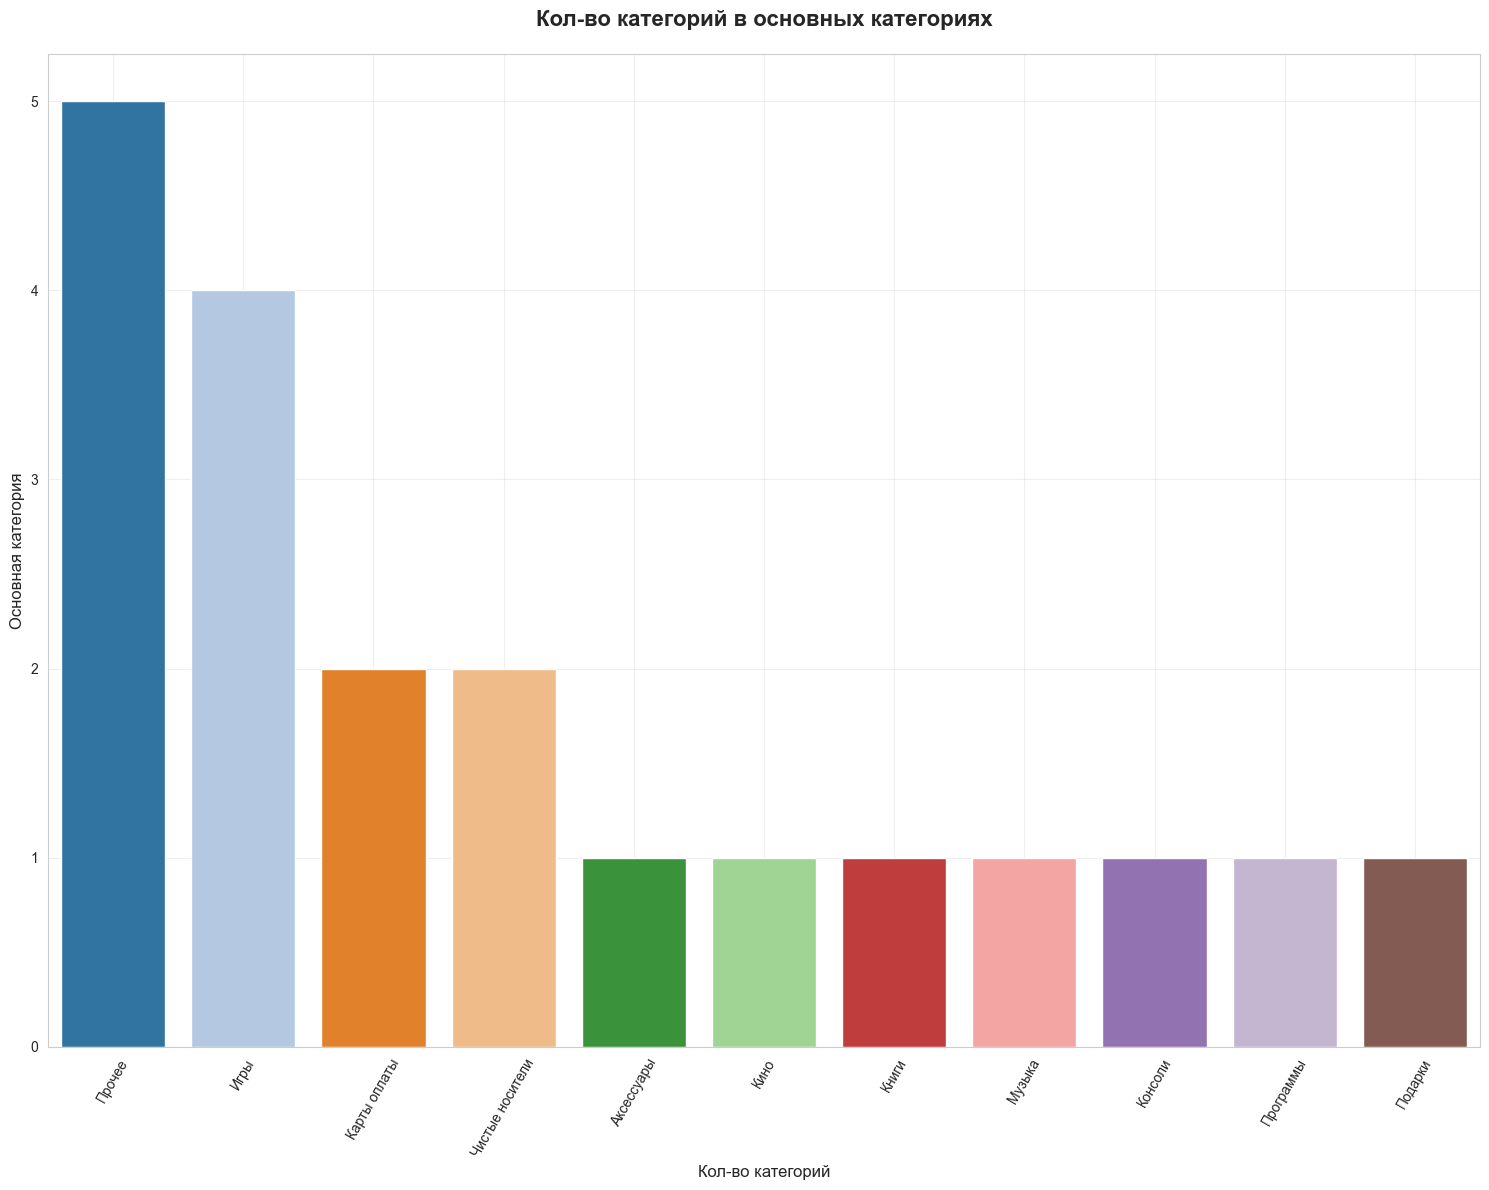

In [235]:
make_count_barplot(data=item_categories, groupby="super_category", aggregate="main_category", 
                   title="Кол-во категорий в основных категориях", 
                   xlabel="Кол-во категорий", ylabel="Основная категория", 
                   file_name= "main_categories_in_super_category", annotation=False,
                   top_n=0)

## Товары

In [236]:
items = pd.read_csv('data/raw/items.csv')
items.head()

,item_name,item_id,item_category_id
0,! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.) D,0,40
1,!ABBYY FineReader 12 Professional Edition Full...,1,76
2,***В ЛУЧАХ СЛАВЫ (UNV) D,2,40
3,***ГОЛУБАЯ ВОЛНА (Univ) D,3,40
4,***КОРОБКА (СТЕКЛО) D,4,40


In [237]:
items.shape

(22170, 3)

In [238]:
items.info()

<class 'pandas.DataFrame'>
RangeIndex: 22170 entries, 0 to 22169
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   item_name         22170 non-null  str  
 1   item_id           22170 non-null  int64
 2   item_category_id  22170 non-null  int64
dtypes: int64(2), str(1)
memory usage: 519.7 KB


In [239]:
# дубликаты

items.duplicated().sum()

np.int64(0)

In [240]:
# isna

items.isna().sum()

item_name           0
item_id             0
item_category_id    0
dtype: int64

In [241]:
# уникальность

items.item_name.nunique()

22170

In [242]:
items['item_category_id'].value_counts()

item_category_id
40    5035
55    2365
37    1780
31    1125
58     790
      ... 
1        2
50       2
10       1
51       1
79       1
Name: count, Length: 84, dtype: int64

In [243]:
items_and_categories = pd.merge(left=items, right= item_categories, how="left", left_on="item_category_id", right_on="item_category_id")

items_and_categories.head()

,item_name,item_id,item_category_id,item_category_name,main_category,super_category
0,! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.) D,0,40,Кино - DVD,Кино,Кино
1,!ABBYY FineReader 12 Professional Edition Full...,1,76,Программы - Для дома и офиса (Цифра),Программы,Программы
2,***В ЛУЧАХ СЛАВЫ (UNV) D,2,40,Кино - DVD,Кино,Кино
3,***ГОЛУБАЯ ВОЛНА (Univ) D,3,40,Кино - DVD,Кино,Кино
4,***КОРОБКА (СТЕКЛО) D,4,40,Кино - DVD,Кино,Кино


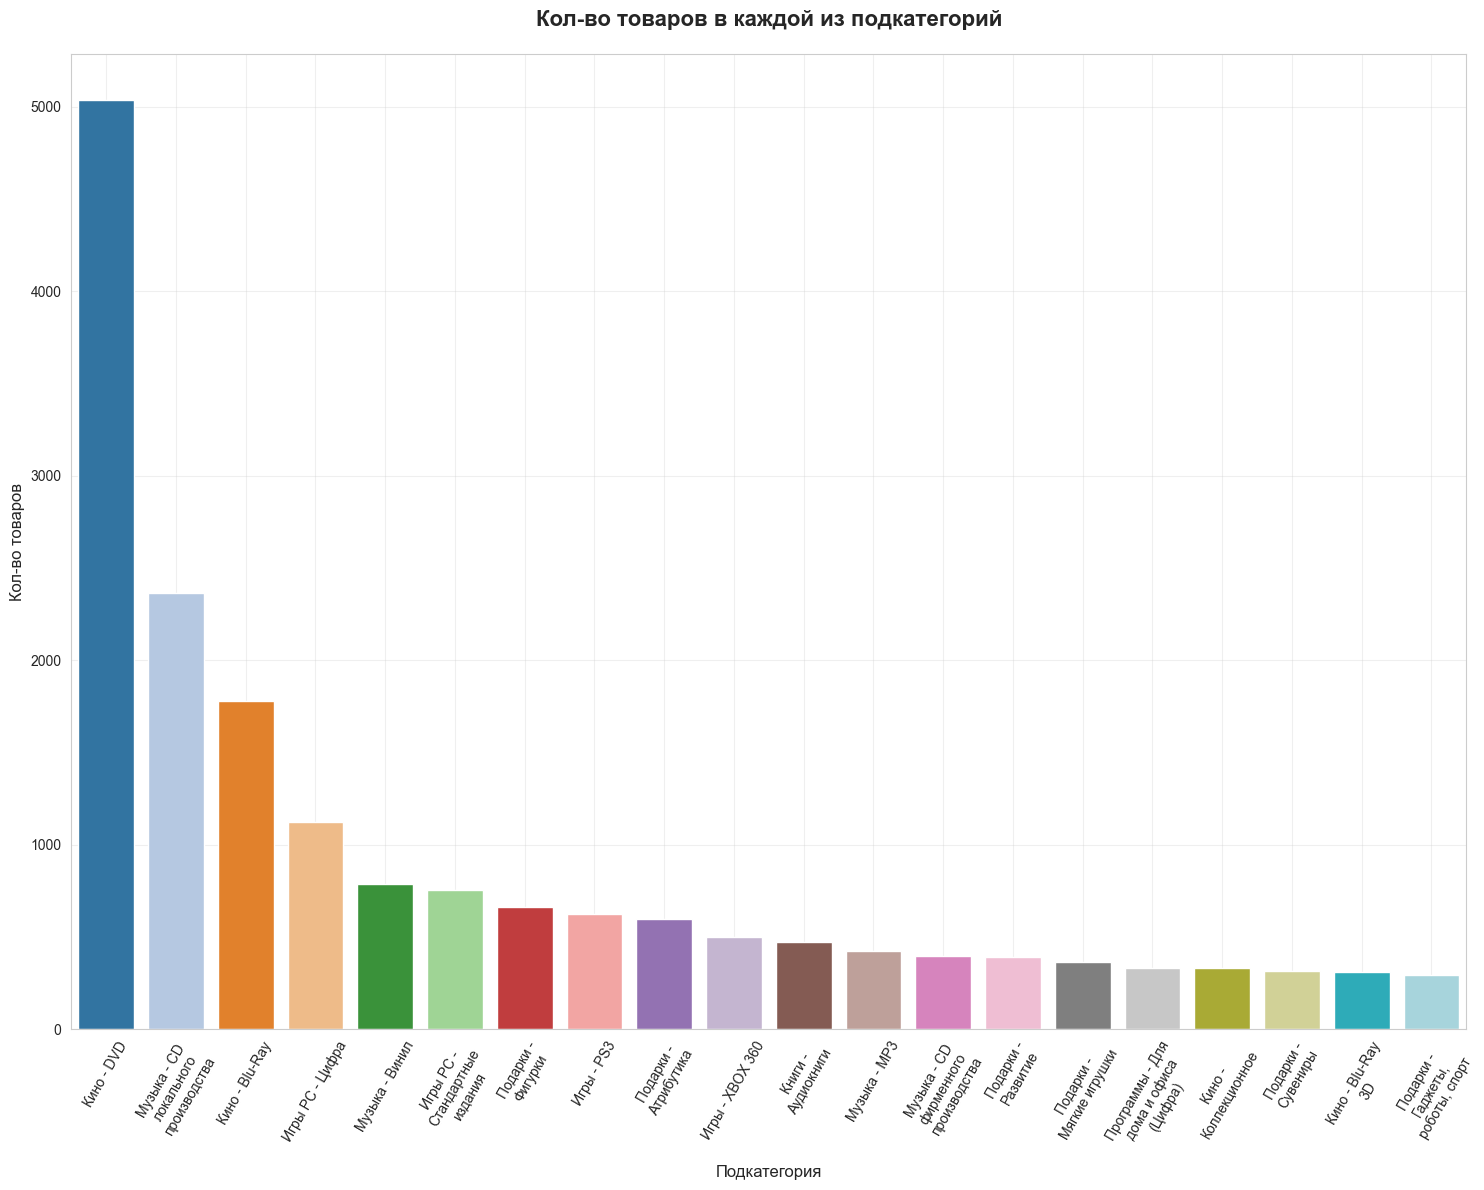

In [244]:
make_count_barplot(data=items_and_categories, groupby="item_category_name", aggregate="item_id", 
                   title="Кол-во товаров в каждой из подкатегорий", 
                   xlabel="Подкатегория", ylabel="Кол-во товаров", 
                   file_name= "items_per_categories", annotation=False,
                   top_n=20)

### Кол-во товаров в топ-20 подкатегориях, с названиями подкатегорий

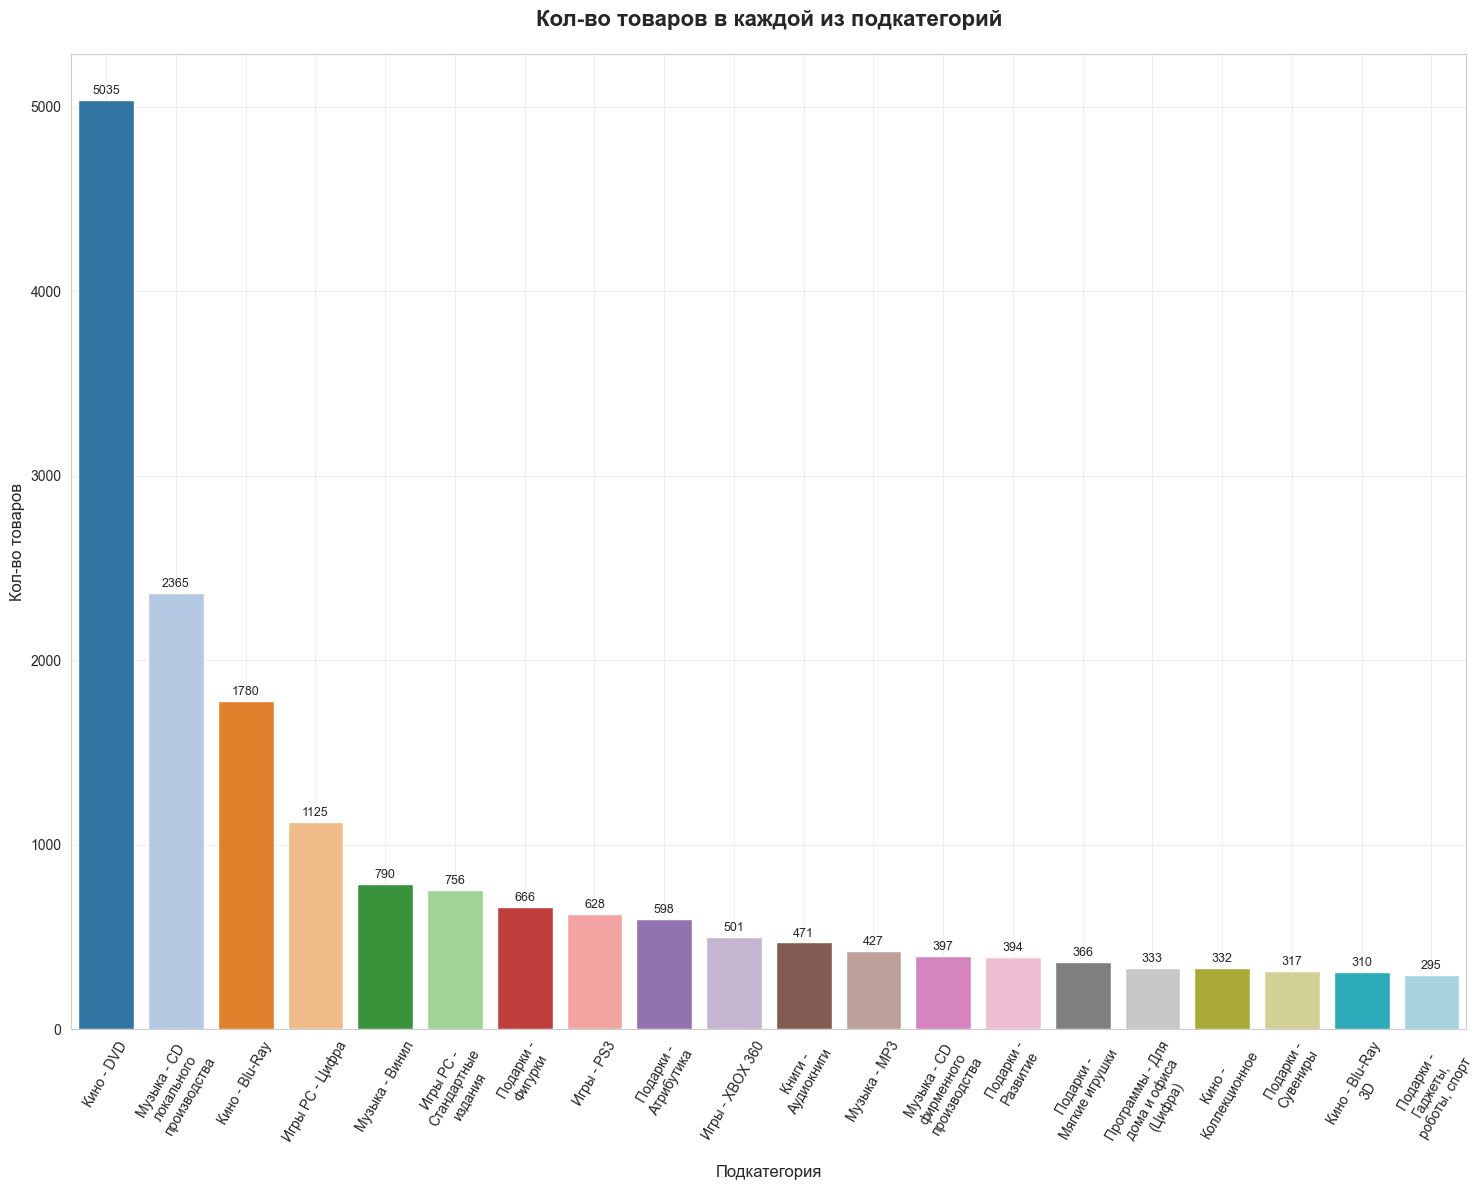

In [245]:
make_count_barplot(data=items_and_categories, groupby="item_category_name", aggregate="item_id", 
                   title="Кол-во товаров в каждой из подкатегорий", 
                   xlabel="Подкатегория", ylabel="Кол-во товаров", 
                   file_name= "items_per_top_20_categories", annotation=True,
                   top_n=20)

### Кол-во товаров в главых категориях

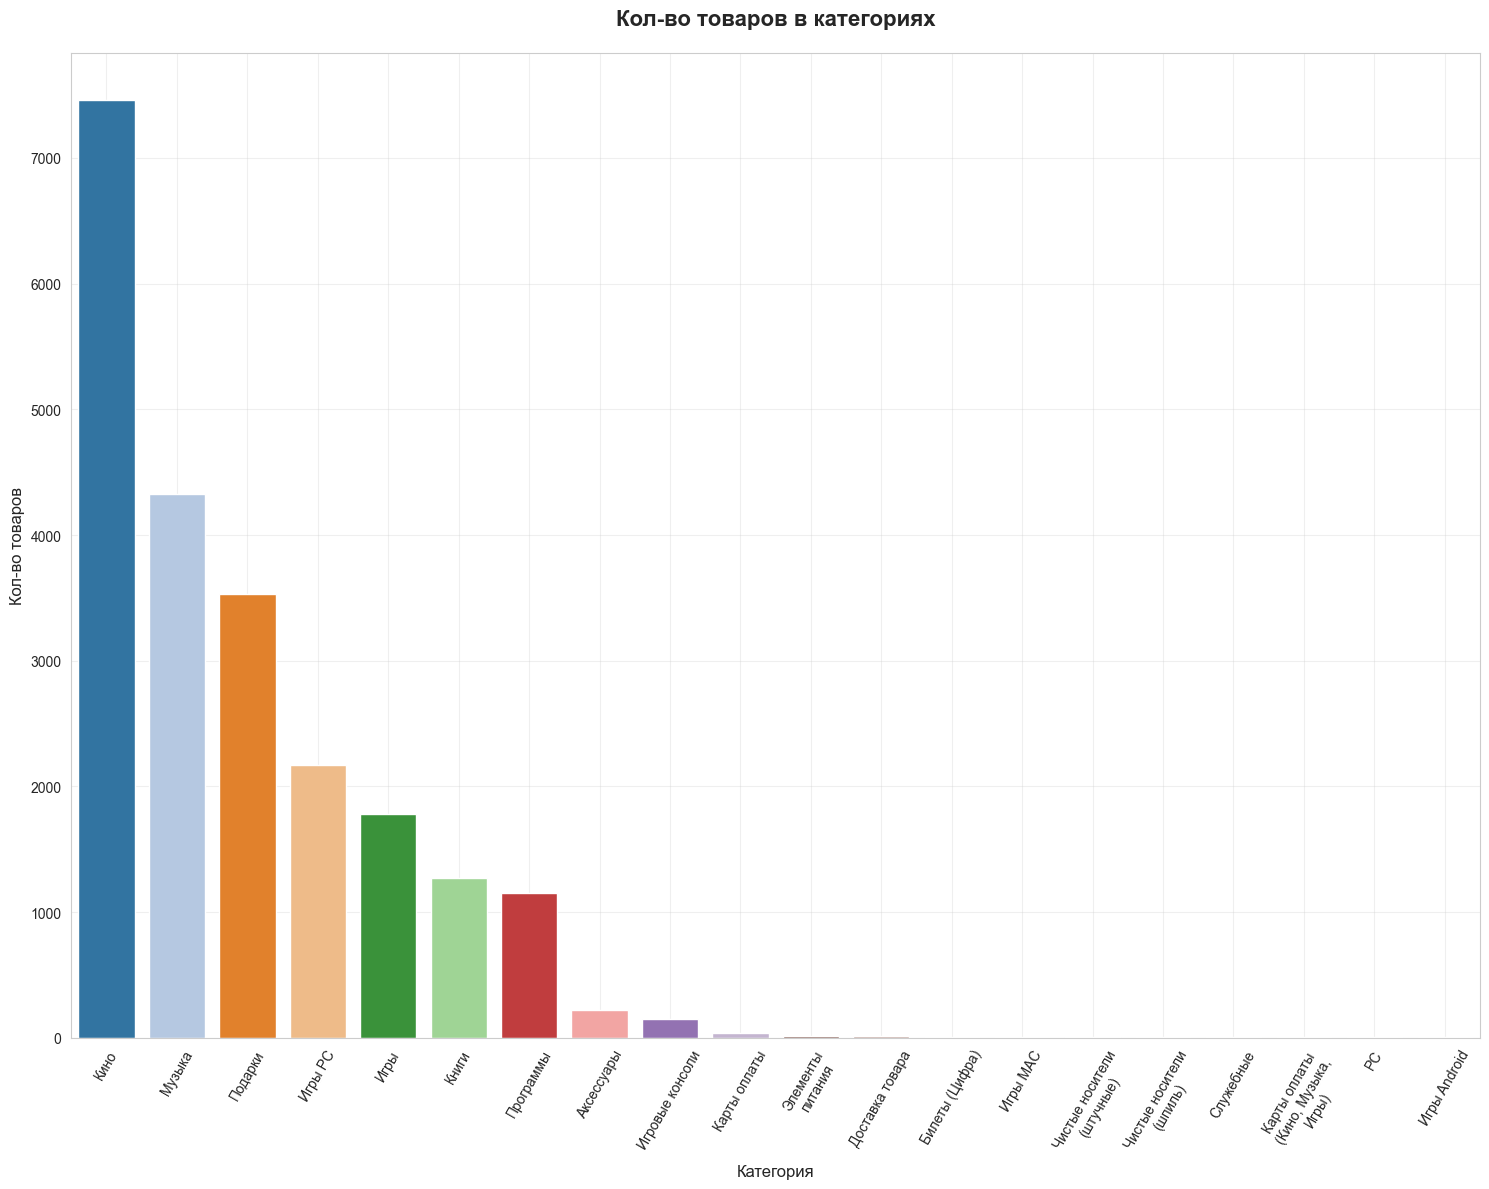

In [246]:
make_count_barplot(data=items_and_categories, groupby="main_category", aggregate="item_id", 
                   title="Кол-во товаров в категориях", 
                   xlabel="Категория", ylabel="Кол-во товаров", 
                   file_name= "items_per_main_categories", annotation=False,
                   top_n=0)

### Кол-во товаров внути Мета-категорий

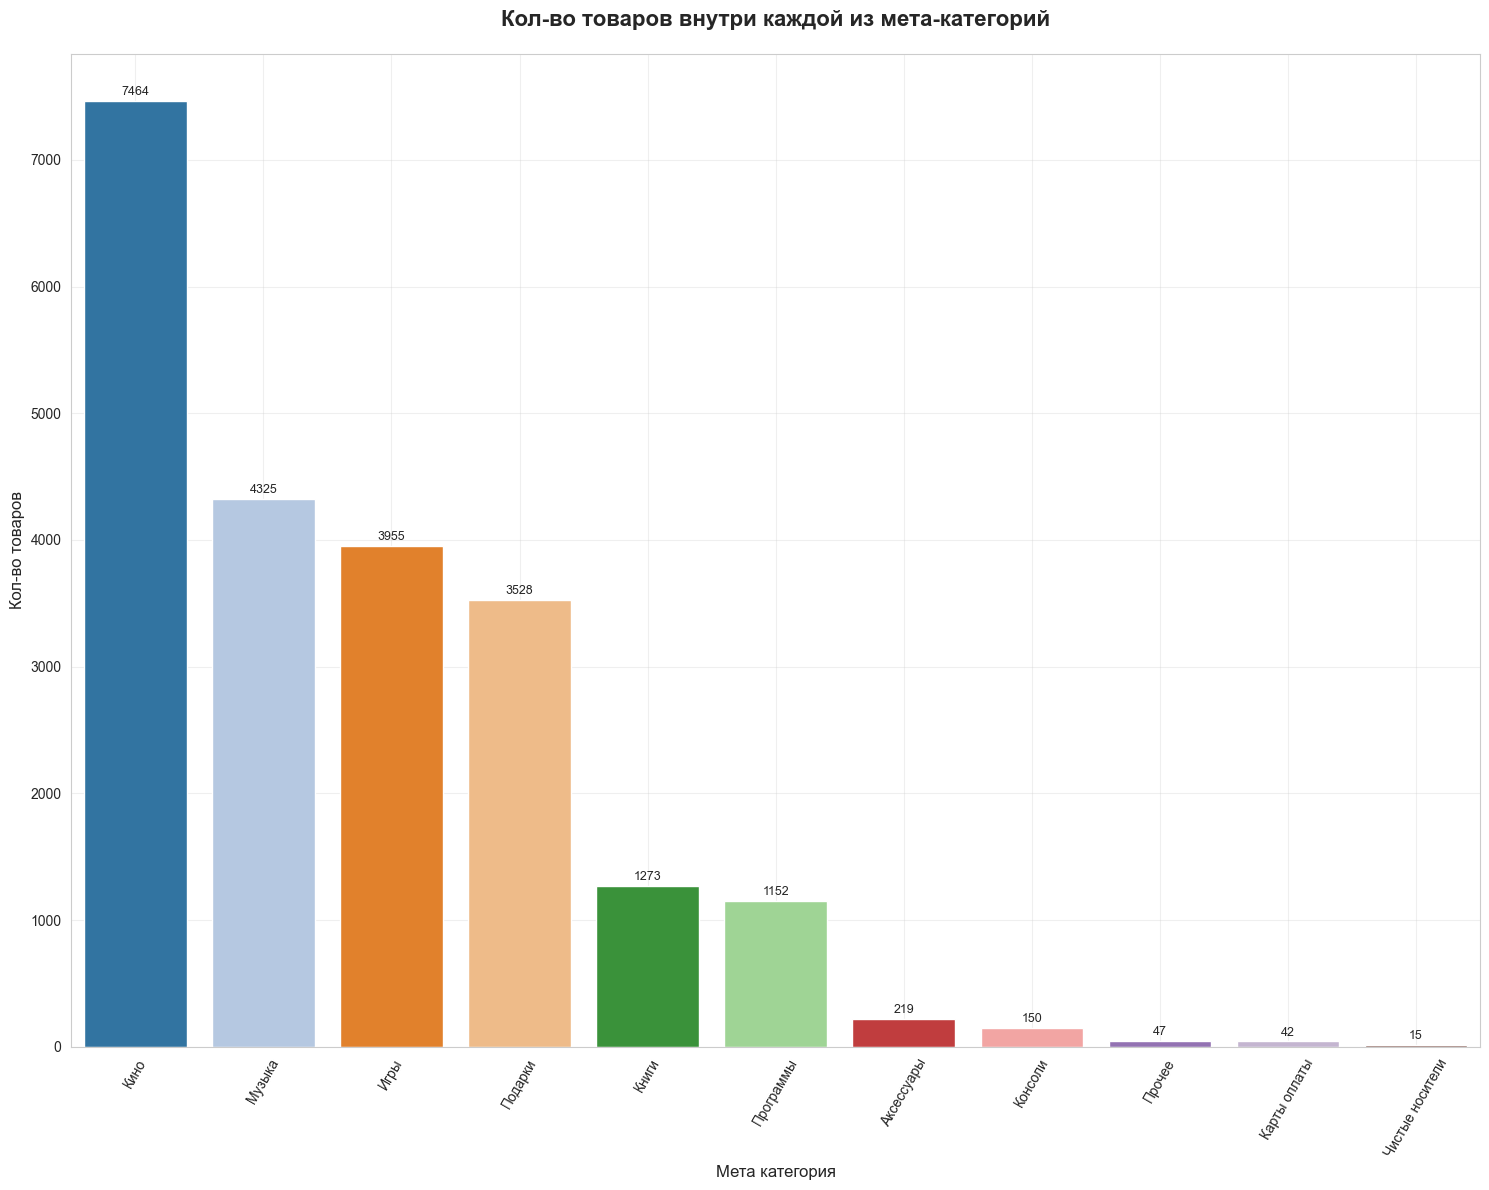

In [247]:
make_count_barplot(data=items_and_categories, groupby="super_category", aggregate="item_id", 
                   title="Кол-во товаров внутри каждой из мета-категорий", 
                   xlabel="Мета категория", ylabel="Кол-во товаров", 
                   file_name= "items_per_super_categories", annotation=True,
                   top_n=0)

## Магазины

In [248]:
shops = pd.read_csv("data/raw/shops.csv")

shops.head()

,shop_name,shop_id
0,"!Якутск Орджоникидзе, 56 фран",0
1,"!Якутск ТЦ ""Центральный"" фран",1
2,"Адыгея ТЦ ""Мега""",2
3,"Балашиха ТРК ""Октябрь-Киномир""",3
4,"Волжский ТЦ ""Волга Молл""",4


In [249]:
shops.shape

(60, 2)

In [250]:
shops.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   shop_name  60 non-null     str  
 1   shop_id    60 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1.1 KB


In [251]:
# дубликаты

shops.duplicated().sum()

np.int64(0)

In [252]:
# isna

shops.isna().sum()

shop_name    0
shop_id      0
dtype: int64

In [253]:
# уникальность

shops.shop_name.nunique()

60

### Работа с городами магазинов

In [254]:
print([shop for shop in shops.shop_name])

['!Якутск Орджоникидзе, 56 фран', '!Якутск ТЦ "Центральный" фран', 'Адыгея ТЦ "Мега"', 'Балашиха ТРК "Октябрь-Киномир"', 'Волжский ТЦ "Волга Молл"', 'Вологда ТРЦ "Мармелад"', 'Воронеж (Плехановская, 13)', 'Воронеж ТРЦ "Максимир"', 'Воронеж ТРЦ Сити-Парк "Град"', 'Выездная Торговля', 'Жуковский ул. Чкалова 39м?', 'Жуковский ул. Чкалова 39м²', 'Интернет-магазин ЧС', 'Казань ТЦ "Бехетле"', 'Казань ТЦ "ПаркХаус" II', 'Калуга ТРЦ "XXI век"', 'Коломна ТЦ "Рио"', 'Красноярск ТЦ "Взлетка Плаза"', 'Красноярск ТЦ "Июнь"', 'Курск ТЦ "Пушкинский"', 'Москва "Распродажа"', 'Москва МТРЦ "Афи Молл"', 'Москва Магазин С21', 'Москва ТК "Буденовский" (пав.А2)', 'Москва ТК "Буденовский" (пав.К7)', 'Москва ТРК "Атриум"', 'Москва ТЦ "Ареал" (Беляево)', 'Москва ТЦ "МЕГА Белая Дача II"', 'Москва ТЦ "МЕГА Теплый Стан" II', 'Москва ТЦ "Новый век" (Новокосино)', 'Москва ТЦ "Перловский"', 'Москва ТЦ "Семеновский"', 'Москва ТЦ "Серебряный Дом"', 'Мытищи ТРК "XL-3"', 'Н.Новгород ТРЦ "РИО"', 'Н.Новгород ТРЦ "Фантасти

In [255]:
shops[shops["shop_name"] == '!Якутск ТЦ "Центральный" фран']

,shop_name,shop_id
1,"!Якутск ТЦ ""Центральный"" фран",1


In [256]:
# удаление восклицательного знака в начале магазина
for shop in shops.shop_name:
    if shop.startswith("!"):
        shops['shop_name'] = shops['shop_name'].replace(shop, shop[1:])
    if shop.endswith("фран"):
        shops['shop_name'] = shops['shop_name'].replace(shop, shop[:-5])

print("Повторов: ", shops['shop_name'].duplicated().sum())
print([shop for shop in shops.shop_name])



Повторов:  0
['Якутск Орджоникидзе, 56 фран', 'Якутск ТЦ "Центральный" фран', 'Адыгея ТЦ "Мега"', 'Балашиха ТРК "Октябрь-Киномир"', 'Волжский ТЦ "Волга Молл"', 'Вологда ТРЦ "Мармелад"', 'Воронеж (Плехановская, 13)', 'Воронеж ТРЦ "Максимир"', 'Воронеж ТРЦ Сити-Парк "Град"', 'Выездная Торговля', 'Жуковский ул. Чкалова 39м?', 'Жуковский ул. Чкалова 39м²', 'Интернет-магазин ЧС', 'Казань ТЦ "Бехетле"', 'Казань ТЦ "ПаркХаус" II', 'Калуга ТРЦ "XXI век"', 'Коломна ТЦ "Рио"', 'Красноярск ТЦ "Взлетка Плаза"', 'Красноярск ТЦ "Июнь"', 'Курск ТЦ "Пушкинский"', 'Москва "Распродажа"', 'Москва МТРЦ "Афи Молл"', 'Москва Магазин С21', 'Москва ТК "Буденовский" (пав.А2)', 'Москва ТК "Буденовский" (пав.К7)', 'Москва ТРК "Атриум"', 'Москва ТЦ "Ареал" (Беляево)', 'Москва ТЦ "МЕГА Белая Дача II"', 'Москва ТЦ "МЕГА Теплый Стан" II', 'Москва ТЦ "Новый век" (Новокосино)', 'Москва ТЦ "Перловский"', 'Москва ТЦ "Семеновский"', 'Москва ТЦ "Серебряный Дом"', 'Мытищи ТРК "XL-3"', 'Н.Новгород ТРЦ "РИО"', 'Н.Новгород ТР

#### Дублирующиеся магазины

In [257]:
shops[shops.duplicated(subset=['shop_name'], keep=False)].index

RangeIndex(start=0, stop=0, step=1)

In [258]:
for index in [0, 1, 57, 58]:
    print(shops[shops['shop_id'] == index])

                      shop_name  shop_id
0  Якутск Орджоникидзе, 56 фран        0
                      shop_name  shop_id
1  Якутск ТЦ "Центральный" фран        1
                  shop_name  shop_id
57  Якутск Орджоникидзе, 56       57
                  shop_name  shop_id
58  Якутск ТЦ "Центральный"       58


Считаем, что это одни и теже магазины, потому что находятся по одному и тому же адресу

In [259]:
franchise_to_main = {
    0: 57,
    1: 58,
}

In [260]:
shops = shops[~shops['shop_id'].isin(list(franchise_to_main.keys()))]
shops.head()

,shop_name,shop_id
2,"Адыгея ТЦ ""Мега""",2
3,"Балашиха ТРК ""Октябрь-Киномир""",3
4,"Волжский ТЦ ""Волга Молл""",4
5,"Вологда ТРЦ ""Мармелад""",5
6,"Воронеж (Плехановская, 13)",6


#### Проставление городов

In [261]:
cities = []

for shop in shops["shop_name"]:
    city = shop.split()[0]
    cities.append(city)

shops['city'] = cities

shops.head()

,shop_name,shop_id,city
2,"Адыгея ТЦ ""Мега""",2,Адыгея
3,"Балашиха ТРК ""Октябрь-Киномир""",3,Балашиха
4,"Волжский ТЦ ""Волга Молл""",4,Волжский
5,"Вологда ТРЦ ""Мармелад""",5,Вологда
6,"Воронеж (Плехановская, 13)",6,Воронеж


In [262]:
print(f"Кол-во уникальных городов: {shops.city.nunique()}")

Кол-во уникальных городов: 31


### Графики

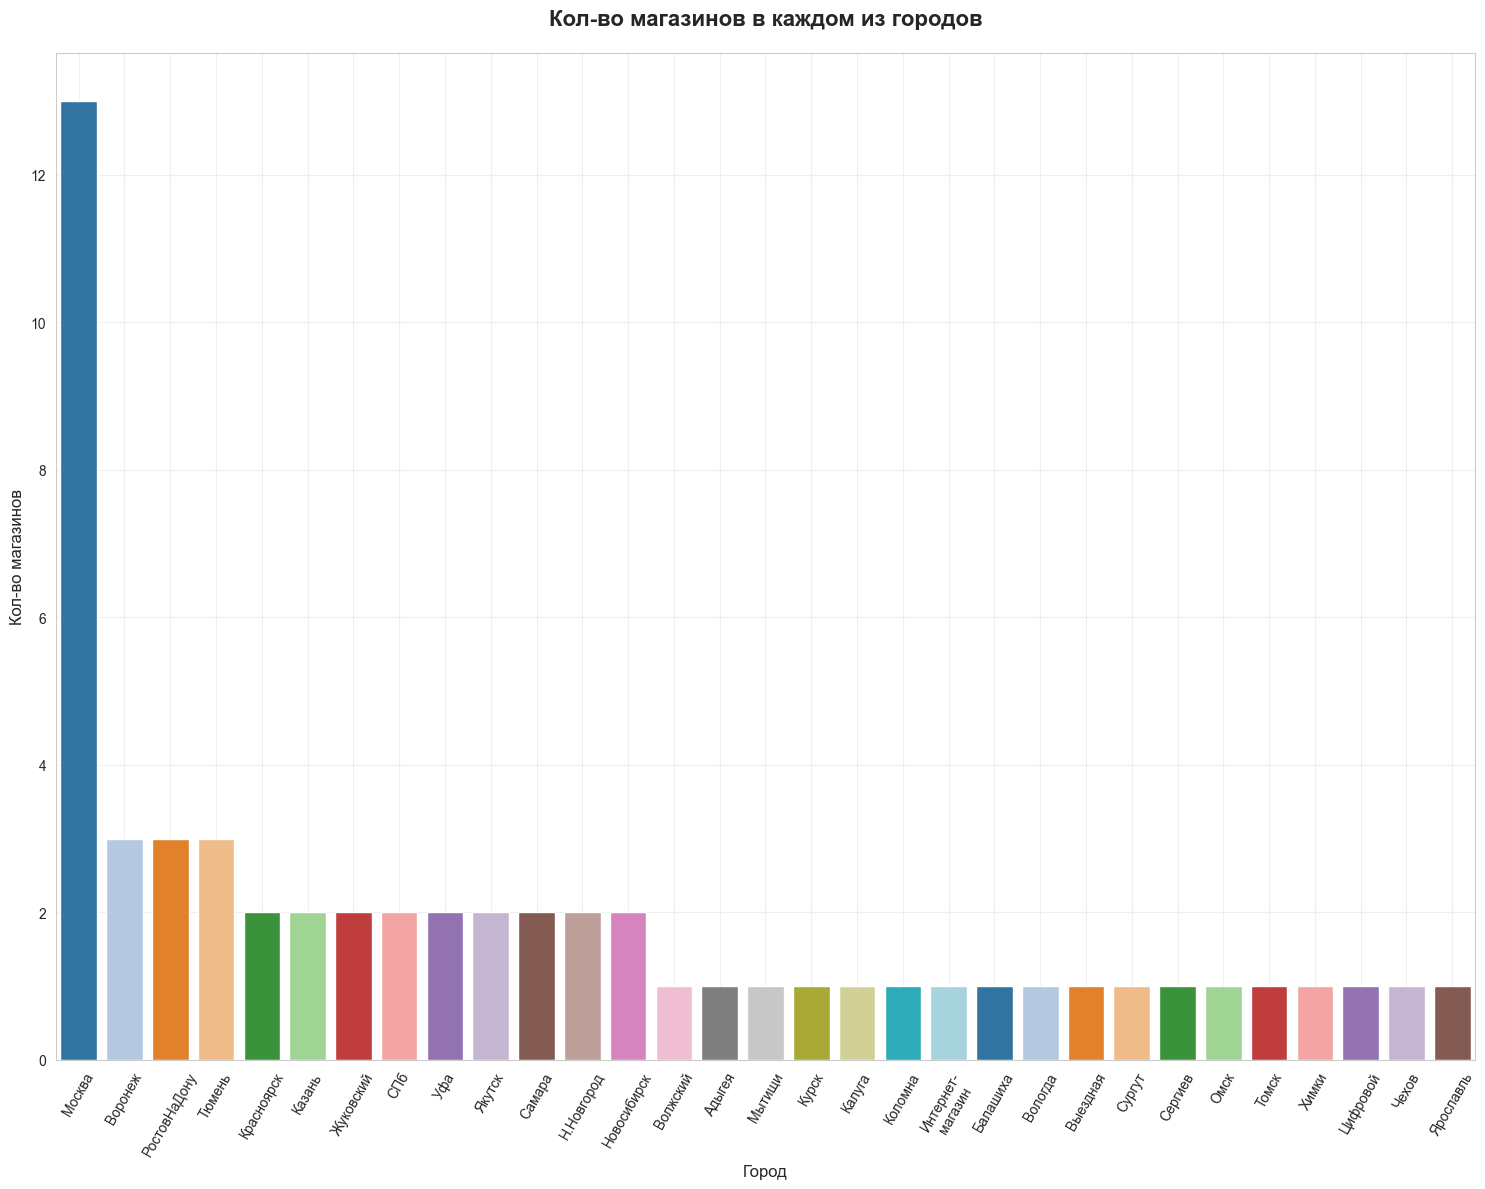

In [263]:
make_count_barplot(data=shops, groupby="city", aggregate="shop_id", 
                   title="Кол-во магазинов в каждом из городов", 
                   xlabel="Город", ylabel="Кол-во магазинов", 
                   file_name= "shops_per_city", annotation=False,
                   top_n= 0)

## Продажи

In [3]:
sales = pd.read_csv("data/raw/sales_train.csv")

sales.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
0,02.01.2013,0,59,22154,999.00,1.0
1,03.01.2013,0,25,2552,899.00,1.0
2,05.01.2013,0,25,2552,899.00,-1.0
3,06.01.2013,0,25,2554,1709.05,1.0
4,15.01.2013,0,25,2555,1099.00,1.0


In [265]:
sales[['item_price', 'item_cnt_day']].describe()

,item_price,item_cnt_day
count,2.935849e+06,2.935849e+06
mean,8.908532e+02,1.242641e+00
std,1.729800e+03,2.618834e+00
min,-1.000000e+00,-2.200000e+01
25%,2.490000e+02,1.000000e+00
50%,3.990000e+02,1.000000e+00
75%,9.990000e+02,1.000000e+00
max,3.079800e+05,2.169000e+03


In [266]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 2935849 entries, 0 to 2935848
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   date            str    
 1   date_block_num  int64  
 2   shop_id         int64  
 3   item_id         int64  
 4   item_price      float64
 5   item_cnt_day    float64
dtypes: float64(2), int64(3), str(1)
memory usage: 134.4 MB


In [267]:
# дубликаты

duplicates_by_key = sales.duplicated(subset=['date', 'shop_id', 'item_id'], keep=False).sum()
print(f"Дубликатов по (date, shop_id, item_id): {duplicates_by_key}")

Дубликатов по (date, shop_id, item_id): 56


In [268]:
dublicate_indexes = list(sales[sales.duplicated(subset=['date', 'shop_id', 'item_id'], keep=False)].index)
print(dublicate_indexes)

[6959, 6960, 70686, 70718, 76961, 76962, 103461, 103463, 142696, 142697, 210156, 210173, 275474, 275476, 284371, 284372, 408103, 408104, 1154619, 1154620, 1203857, 1203858, 1435365, 1435367, 1496765, 1496766, 1507628, 1507629, 1524577, 1524593, 1671872, 1671873, 1866322, 1866340, 1890002, 1890003, 1940056, 1940058, 2110311, 2110313, 2198564, 2198566, 2213869, 2213870, 2231653, 2231657, 2272100, 2272101, 2420538, 2420539, 2456813, 2456815, 2475957, 2475963, 2909372, 2909373]


In [269]:
for index in dublicate_indexes:
    print(sales.iloc[index]['date'])

29.01.2013
29.01.2013
25.01.2013
25.01.2013
05.01.2013
05.01.2013
27.01.2013
27.01.2013
18.02.2013
18.02.2013
16.02.2013
16.02.2013
07.03.2013
07.03.2013
02.03.2013
02.03.2013
06.04.2013
06.04.2013
29.12.2013
29.12.2013
28.12.2013
28.12.2013
23.02.2014
23.02.2014
23.03.2014
23.03.2014
09.03.2014
09.03.2014
30.03.2014
30.03.2014
01.05.2014
01.05.2014
12.07.2014
12.07.2014
16.08.2014
16.08.2014
14.08.2014
14.08.2014
21.11.2014
21.11.2014
31.12.2014
31.12.2014
31.12.2014
31.12.2014
22.12.2014
22.12.2014
26.12.2014
26.12.2014
12.02.2015
12.02.2015
17.02.2015
17.02.2015
21.02.2015
21.02.2015
07.10.2015
07.10.2015


In [270]:
sales.iloc[70686]

date              25.01.2013
date_block_num             0
shop_id                   31
item_id                14050
item_price             349.0
item_cnt_day             1.0
Name: 70686, dtype: object

In [271]:
sales.iloc[70718]

date              25.01.2013
date_block_num             0
shop_id                   31
item_id                14050
item_price             248.0
item_cnt_day             1.0
Name: 70718, dtype: object

Один и тот же товар, но с разными ценниками.

In [272]:
# усреднение цены таких товаров

sales = sales.groupby(['date', 'date_block_num', 'shop_id', 'item_id'], as_index=False).agg({
    'item_cnt_day': 'sum',
    'item_price': 'mean'
})

In [273]:
duplicates_by_key = sales.duplicated(subset=['date', 'shop_id', 'item_id'], keep=False).sum()
print(f"Дубликатов по (date, shop_id, item_id): {duplicates_by_key}")

Дубликатов по (date, shop_id, item_id): 0


дубликатов больше нет

In [274]:
result = sales.query("date == '25.01.2013' and shop_id == 31 and item_id == 14050")
result

,date,date_block_num,shop_id,item_id,item_cnt_day,item_price
2293697,25.01.2013,0,31,14050,2.0,298.5


In [275]:
# isna

sales.isna().sum()

date              0
date_block_num    0
shop_id           0
item_id           0
item_cnt_day      0
item_price        0
dtype: int64

In [276]:
sales['shop_id'] = sales['shop_id'].replace(franchise_to_main) # замена магазинов по франшизам

### Возвращенных товаров

In [6]:
len(sales[sales['item_cnt_day'] < 0])

7356

## Добавление информации о магазинах и товаров в продажи

In [277]:
full_sales_info = sales.copy(deep=True)
full_sales_info

,date,date_block_num,shop_id,item_id,item_cnt_day,item_price
0,01.01.2013,0,2,991,1.0,99.0
1,01.01.2013,0,2,1472,1.0,2599.0
2,01.01.2013,0,2,1905,1.0,249.0
3,01.01.2013,0,2,2920,2.0,599.0
4,01.01.2013,0,2,3320,1.0,1999.0
...,...,...,...,...,...,...
2935816,31.12.2014,23,59,20404,1.0,2399.0
2935817,31.12.2014,23,59,20610,1.0,1099.0
2935818,31.12.2014,23,59,20949,5.0,5.0
2935819,31.12.2014,23,59,21762,1.0,1499.0


In [278]:
full_sales_info = pd.merge(left= full_sales_info, right= items_and_categories, 
                           how= 'left', left_on= 'item_id', right_on= 'item_id')\
                    .merge(right= shops, 
                           how= 'left', left_on= 'shop_id', right_on= 'shop_id')

full_sales_info['total_price'] = full_sales_info["item_cnt_day"] * full_sales_info["item_price"]
full_sales_info.head()


,date,date_block_num,shop_id,item_id,item_cnt_day,item_price,item_name,item_category_id,item_category_name,main_category,super_category,shop_name,city,total_price
0,01.01.2013,0,2,991,1.0,99.0,"3D Action Puzzle ""Динозавры"" Тиранозавр",67,Подарки - Развитие,Подарки,Подарки,"Адыгея ТЦ ""Мега""",Адыгея,99.0
1,01.01.2013,0,2,1472,1.0,2599.0,"Assassin's Creed 3 [Xbox 360, русская версия]",23,Игры - XBOX 360,Игры,Игры,"Адыгея ТЦ ""Мега""",Адыгея,2599.0
2,01.01.2013,0,2,1905,1.0,249.0,"Bestseller. Grand Theft Auto: San Andreas [PC,...",30,Игры PC - Стандартные издания,Игры PC,Игры,"Адыгея ТЦ ""Мега""",Адыгея,249.0
3,01.01.2013,0,2,2920,2.0,599.0,Disney. LEGO Пираты Карибского моря (Essential...,21,Игры - PSP,Игры,Игры,"Адыгея ТЦ ""Мега""",Адыгея,1198.0
4,01.01.2013,0,2,3320,1.0,1999.0,"FIFA 13 (с поддержкой PS Move) [PS3, русская в...",19,Игры - PS3,Игры,Игры,"Адыгея ТЦ ""Мега""",Адыгея,1999.0


In [279]:
full_sales_info['short_item_name'] = [x[:22] +'...' for x in full_sales_info['item_name']]


## Графики

In [291]:
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter

def millions_formatter(x, pos): # Перевод чисел в миллионы
    return f"{x/1e6:.1f} M"  # .1f — одна десятичная точка

def plot_graphs(data: pd.DataFrame, groupby: str, aggregate: str, plot_title: str, file_name: str, top_k: int):
    '''
    Строит 2 bar графика по лучшим и худшим товарам, строит pie диаграмму с top_k категориями + "Остальное"
    '''
    items = data.groupby(groupby)[aggregate].sum().sort_values(ascending=False)
    
    top_k = min(top_k if top_k != 0 else len(items), len(items))
    
    top_items = items[:top_k].reset_index()
    last_items = items[-top_k:].reset_index()
    
    label_dict = {
        "item_category_name": ["Категория", "категорий", "категориям"],
        "short_item_name": ["Товар", "товару", "товарам"],
        "total_price": ["Выручка", "выручке", "выручкам"],
        "super_category": ["Суперкатегория", "суперкатегорий", "суперкатегориям"],
        "item_cnt_day": ["Кол-во продаж", "кол-ву продаж", "кол-вам продаж"],
        "shop_name": ["Магазин", "магазинов", "магазинам"],
        "city": ["Город", "городов", "городам"]
    }
    
    fig = plt.figure(figsize=(25, 20))
    sns.set_style("whitegrid")
    gs = GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1])
    
    # График для лучших
    ax1 = fig.add_subplot(gs[0, 0])
    sns.barplot(data=top_items, x=groupby, y=aggregate, hue=groupby, palette='tab20', ax=ax1,legend=False)

    # График для худших
    ax2 = fig.add_subplot(gs[0, 1])
    sns.barplot(data=last_items, x=groupby, y=aggregate, hue=groupby, palette='tab20', ax=ax2, legend=False)

    for axis in ax1, ax2:
        graph_name = "Топ" if axis == ax1 else "Худшие"
        
        axis.set_title(f"{graph_name} {top_k} {label_dict[groupby][1]} по {label_dict[aggregate][1]}")
        axis.set(xlabel= label_dict[groupby][0], ylabel= label_dict[aggregate][0])
        axis.tick_params(axis='x', rotation=45, labelsize=10)
        axis.grid(True, alpha=0.3, which='both')

    ax1.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
    if groupby == "super_category" or "shop_name":
        ax2.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
    
    # Круговая диаграмма
    ax3 = fig.add_subplot(gs[1, :])
    
    main_categories = items.index[:6].tolist() if len(items.index) > 6 else len(items.index)
    df_pie = items.reset_index(name=aggregate) 
    df_pie[groupby] = df_pie[groupby].apply(lambda x: 'Остальное' if x not in main_categories else x)
    df_grouped = df_pie.groupby(groupby, as_index=False)[aggregate].sum()
    df_grouped = df_grouped.sort_values(aggregate, ascending=False)
    
    categories = df_grouped[groupby]
    pie_values = df_grouped[aggregate]
    total = pie_values.sum()
    
    labels = []
    for cat, val in zip(categories, pie_values):
        pct = 100 * val / total
        labels.append(f"{cat}\n{val/1e6:.1f} M\n({pct:.1f}%)")
    
    colors = sns.color_palette("tab20", n_colors=len(categories))
    ax3.pie(
        pie_values,
        labels=labels,
        colors=colors,
        startangle=90,
        textprops={'fontsize': 10},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        pctdistance=0.75,
        labeldistance=1.05
    )
    ax3.set_title(f"{label_dict[aggregate][0]} по {label_dict[groupby][2]} (с объединением мелких)", 
                  fontsize=16)
    
    fig.suptitle(plot_title, fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f"artifacts/figures/eda/{file_name}.png", dpi=300, bbox_inches='tight')
    plt.show()

### Доходы по супер-категориям

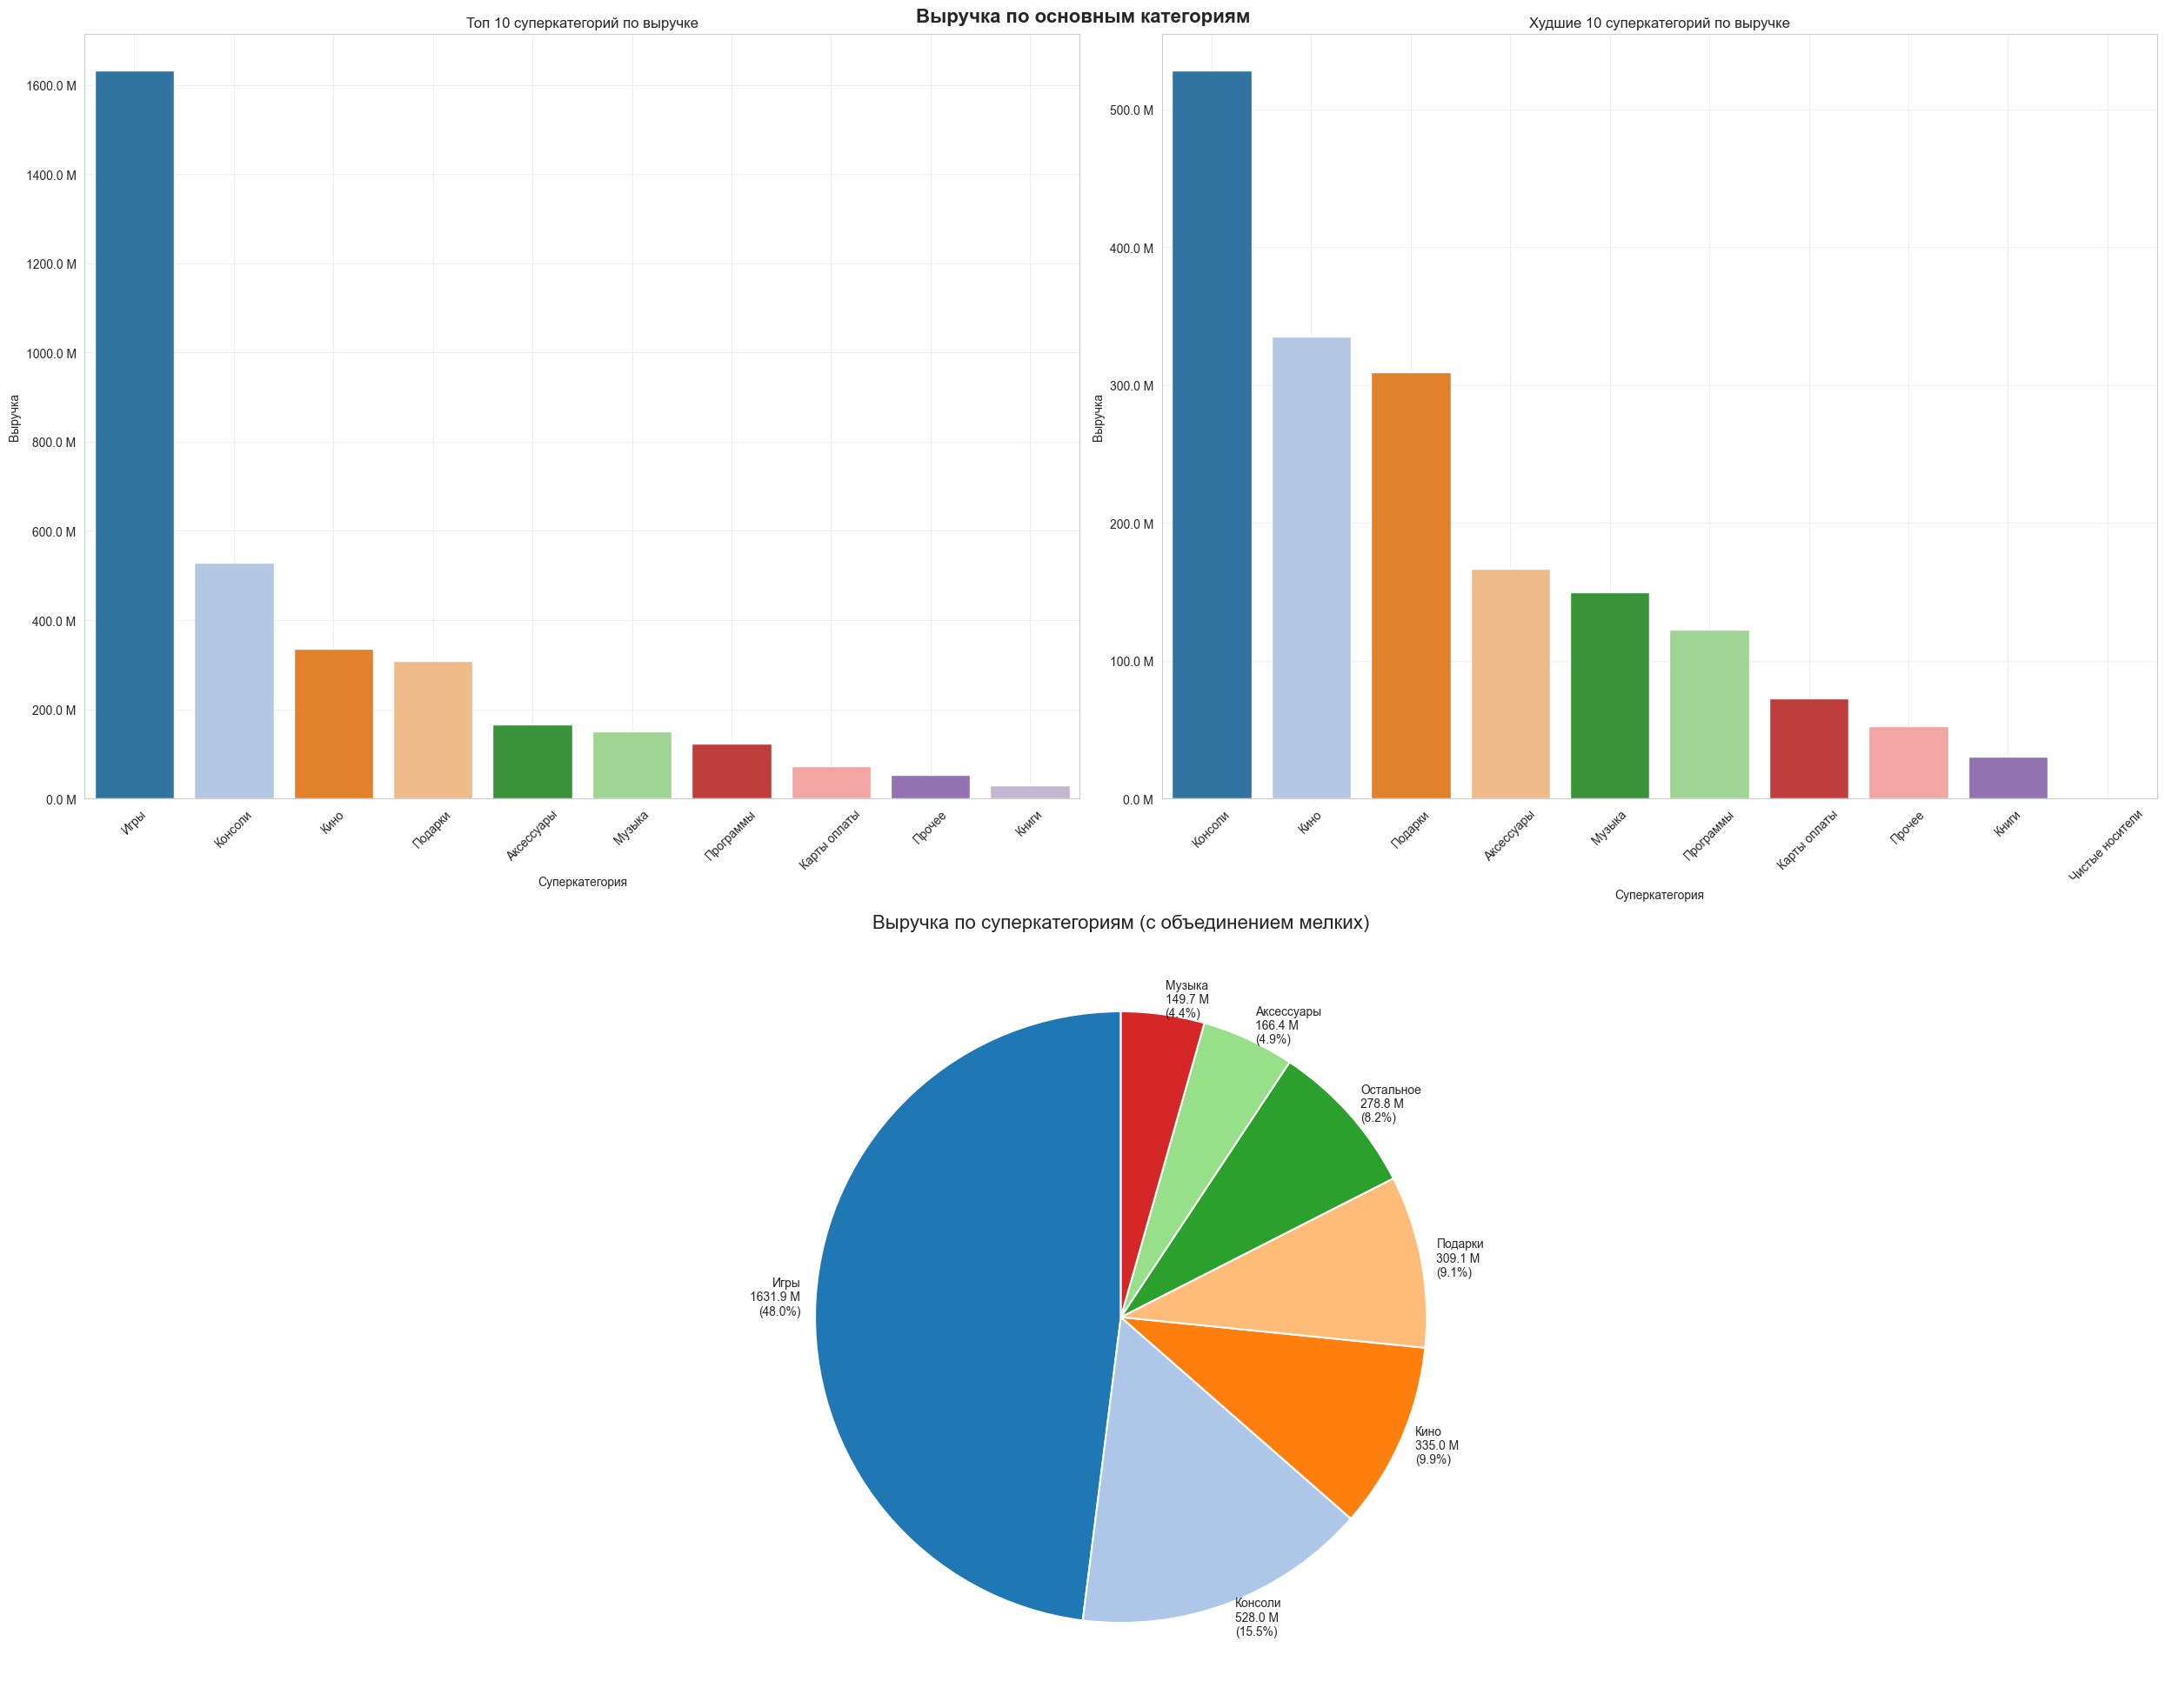

In [281]:
plot_graphs(full_sales_info, "super_category", "total_price", "Выручка по основным категориям", "revenue_by_supercategories", 10)

### Продажи по супер-категориям

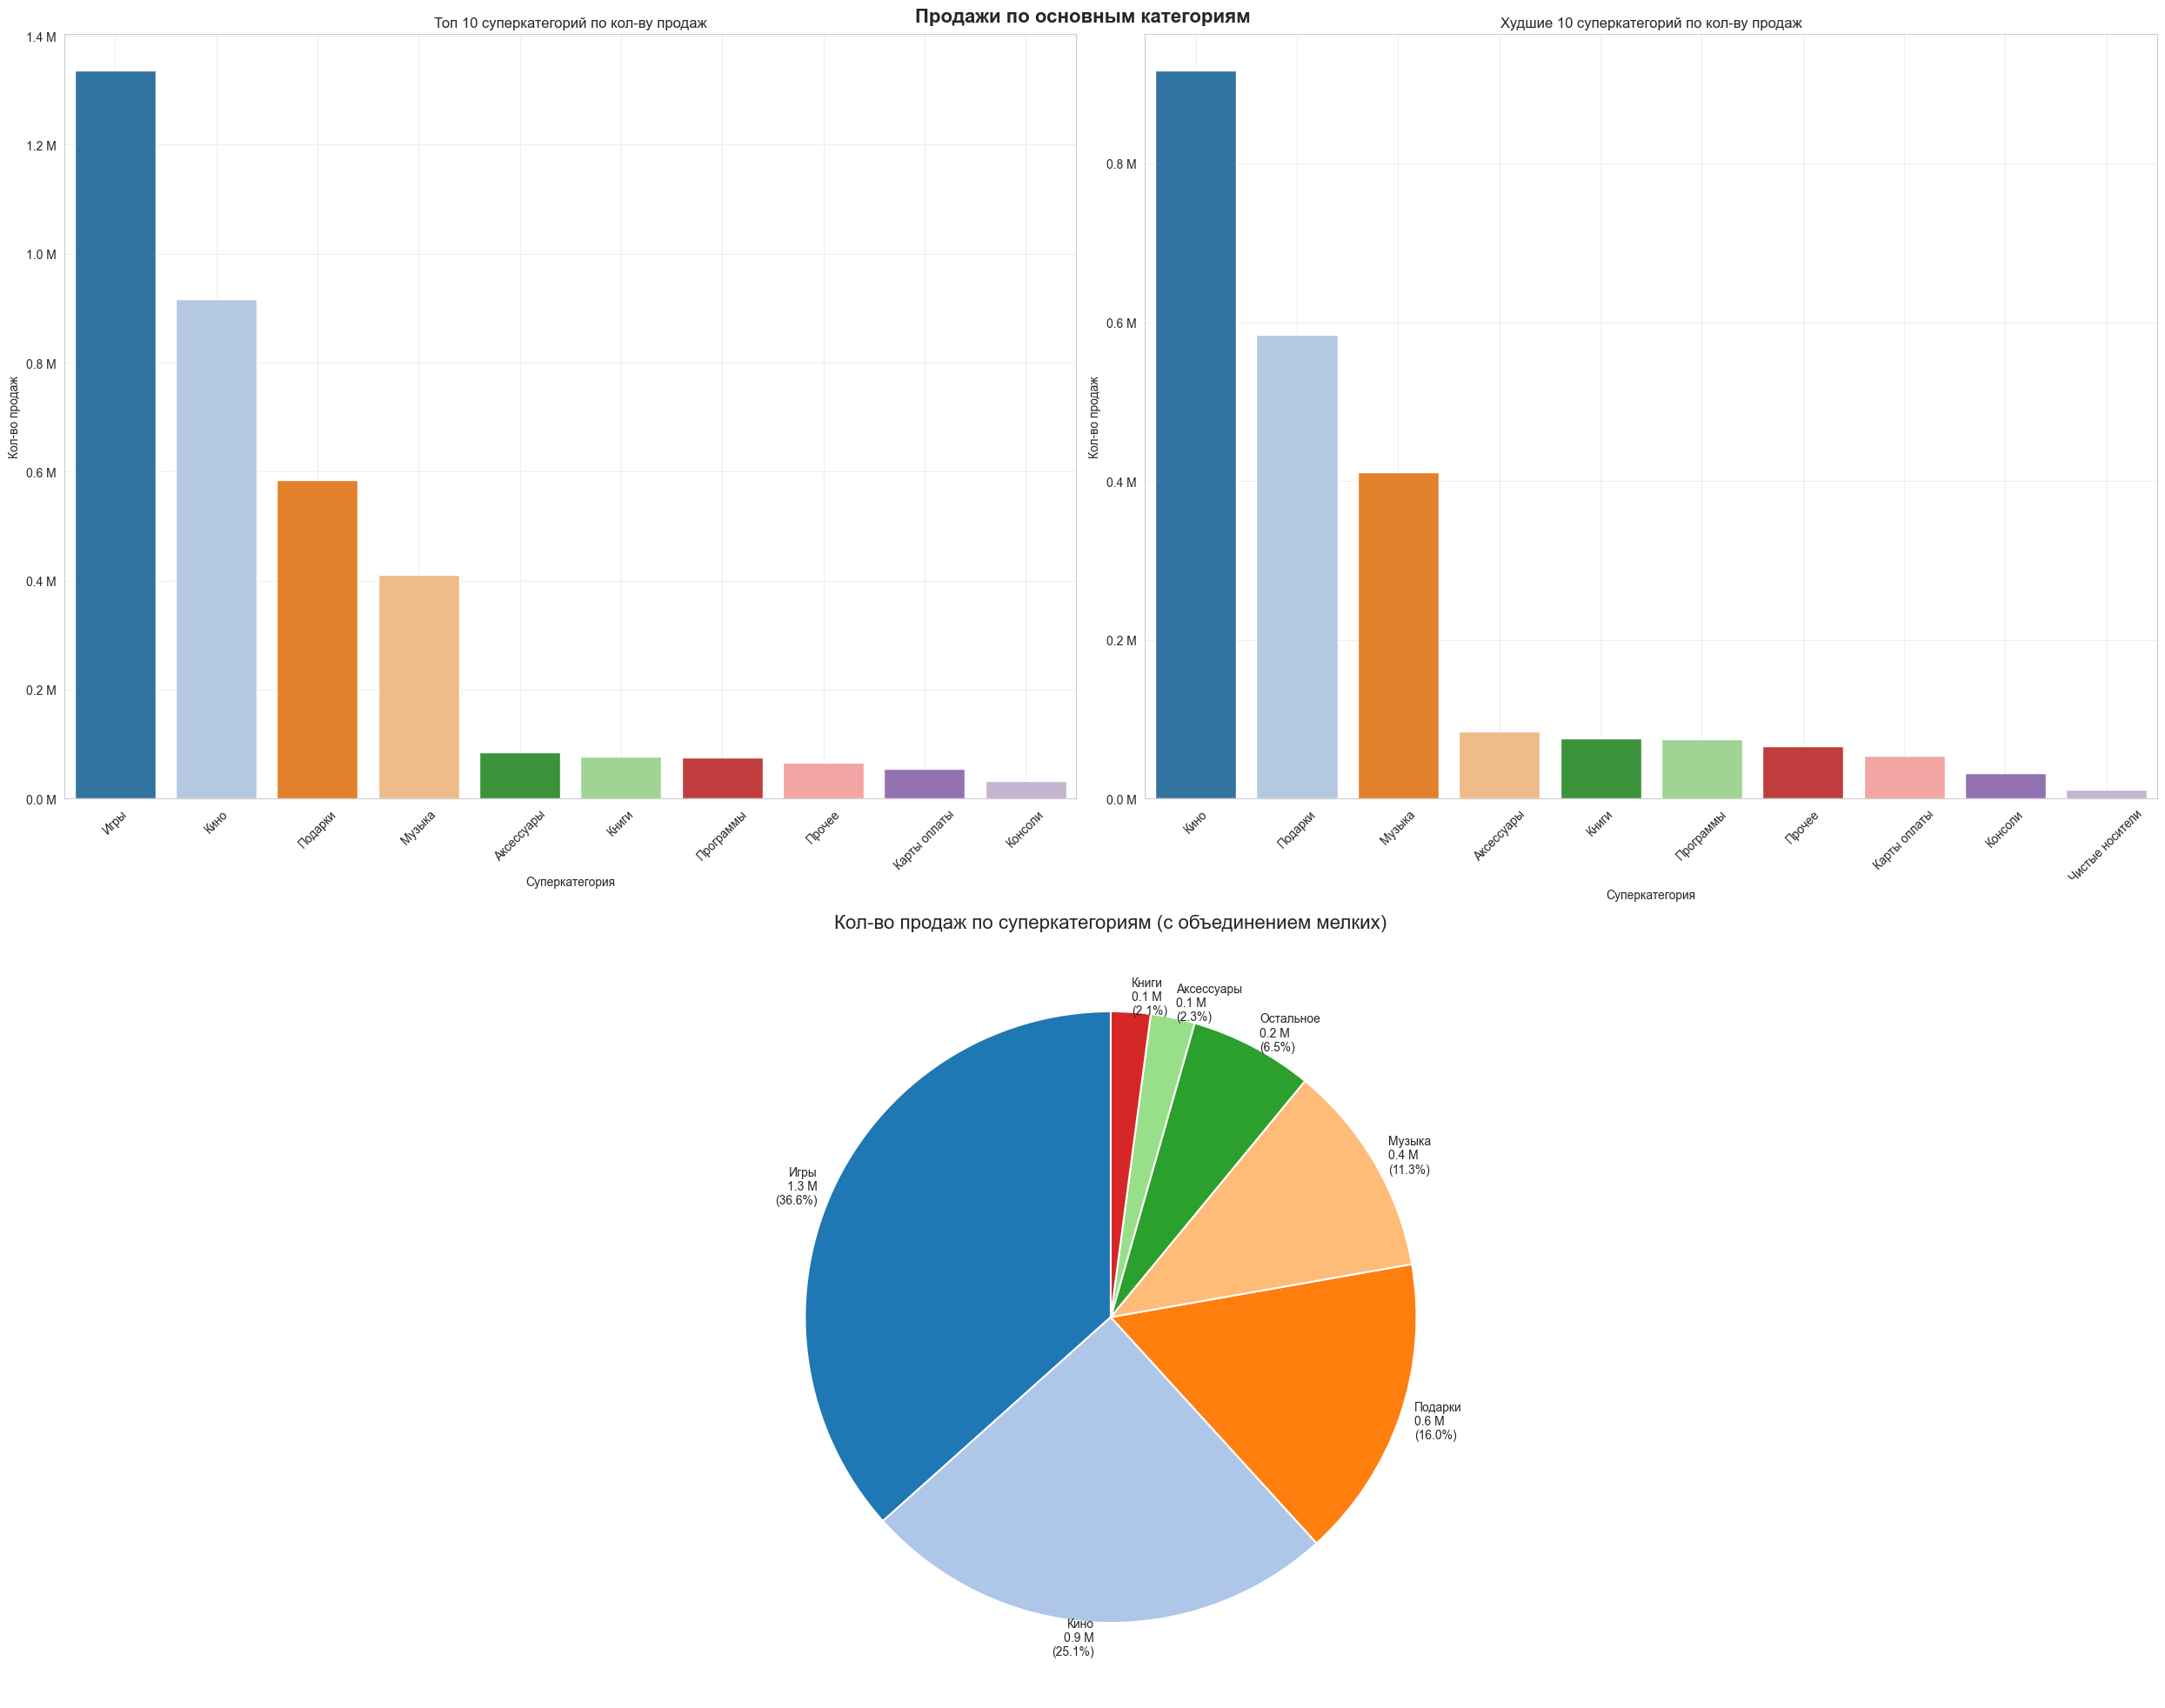

In [282]:
plot_graphs(full_sales_info, "super_category", "item_cnt_day", "Продажи по основным категориям", "sales_by_supercategories", 10)

У музыки много продаж, но доход с нее маленький

У консолей мало продаж, но они делают хорошую выручку

### Выручка по категориям

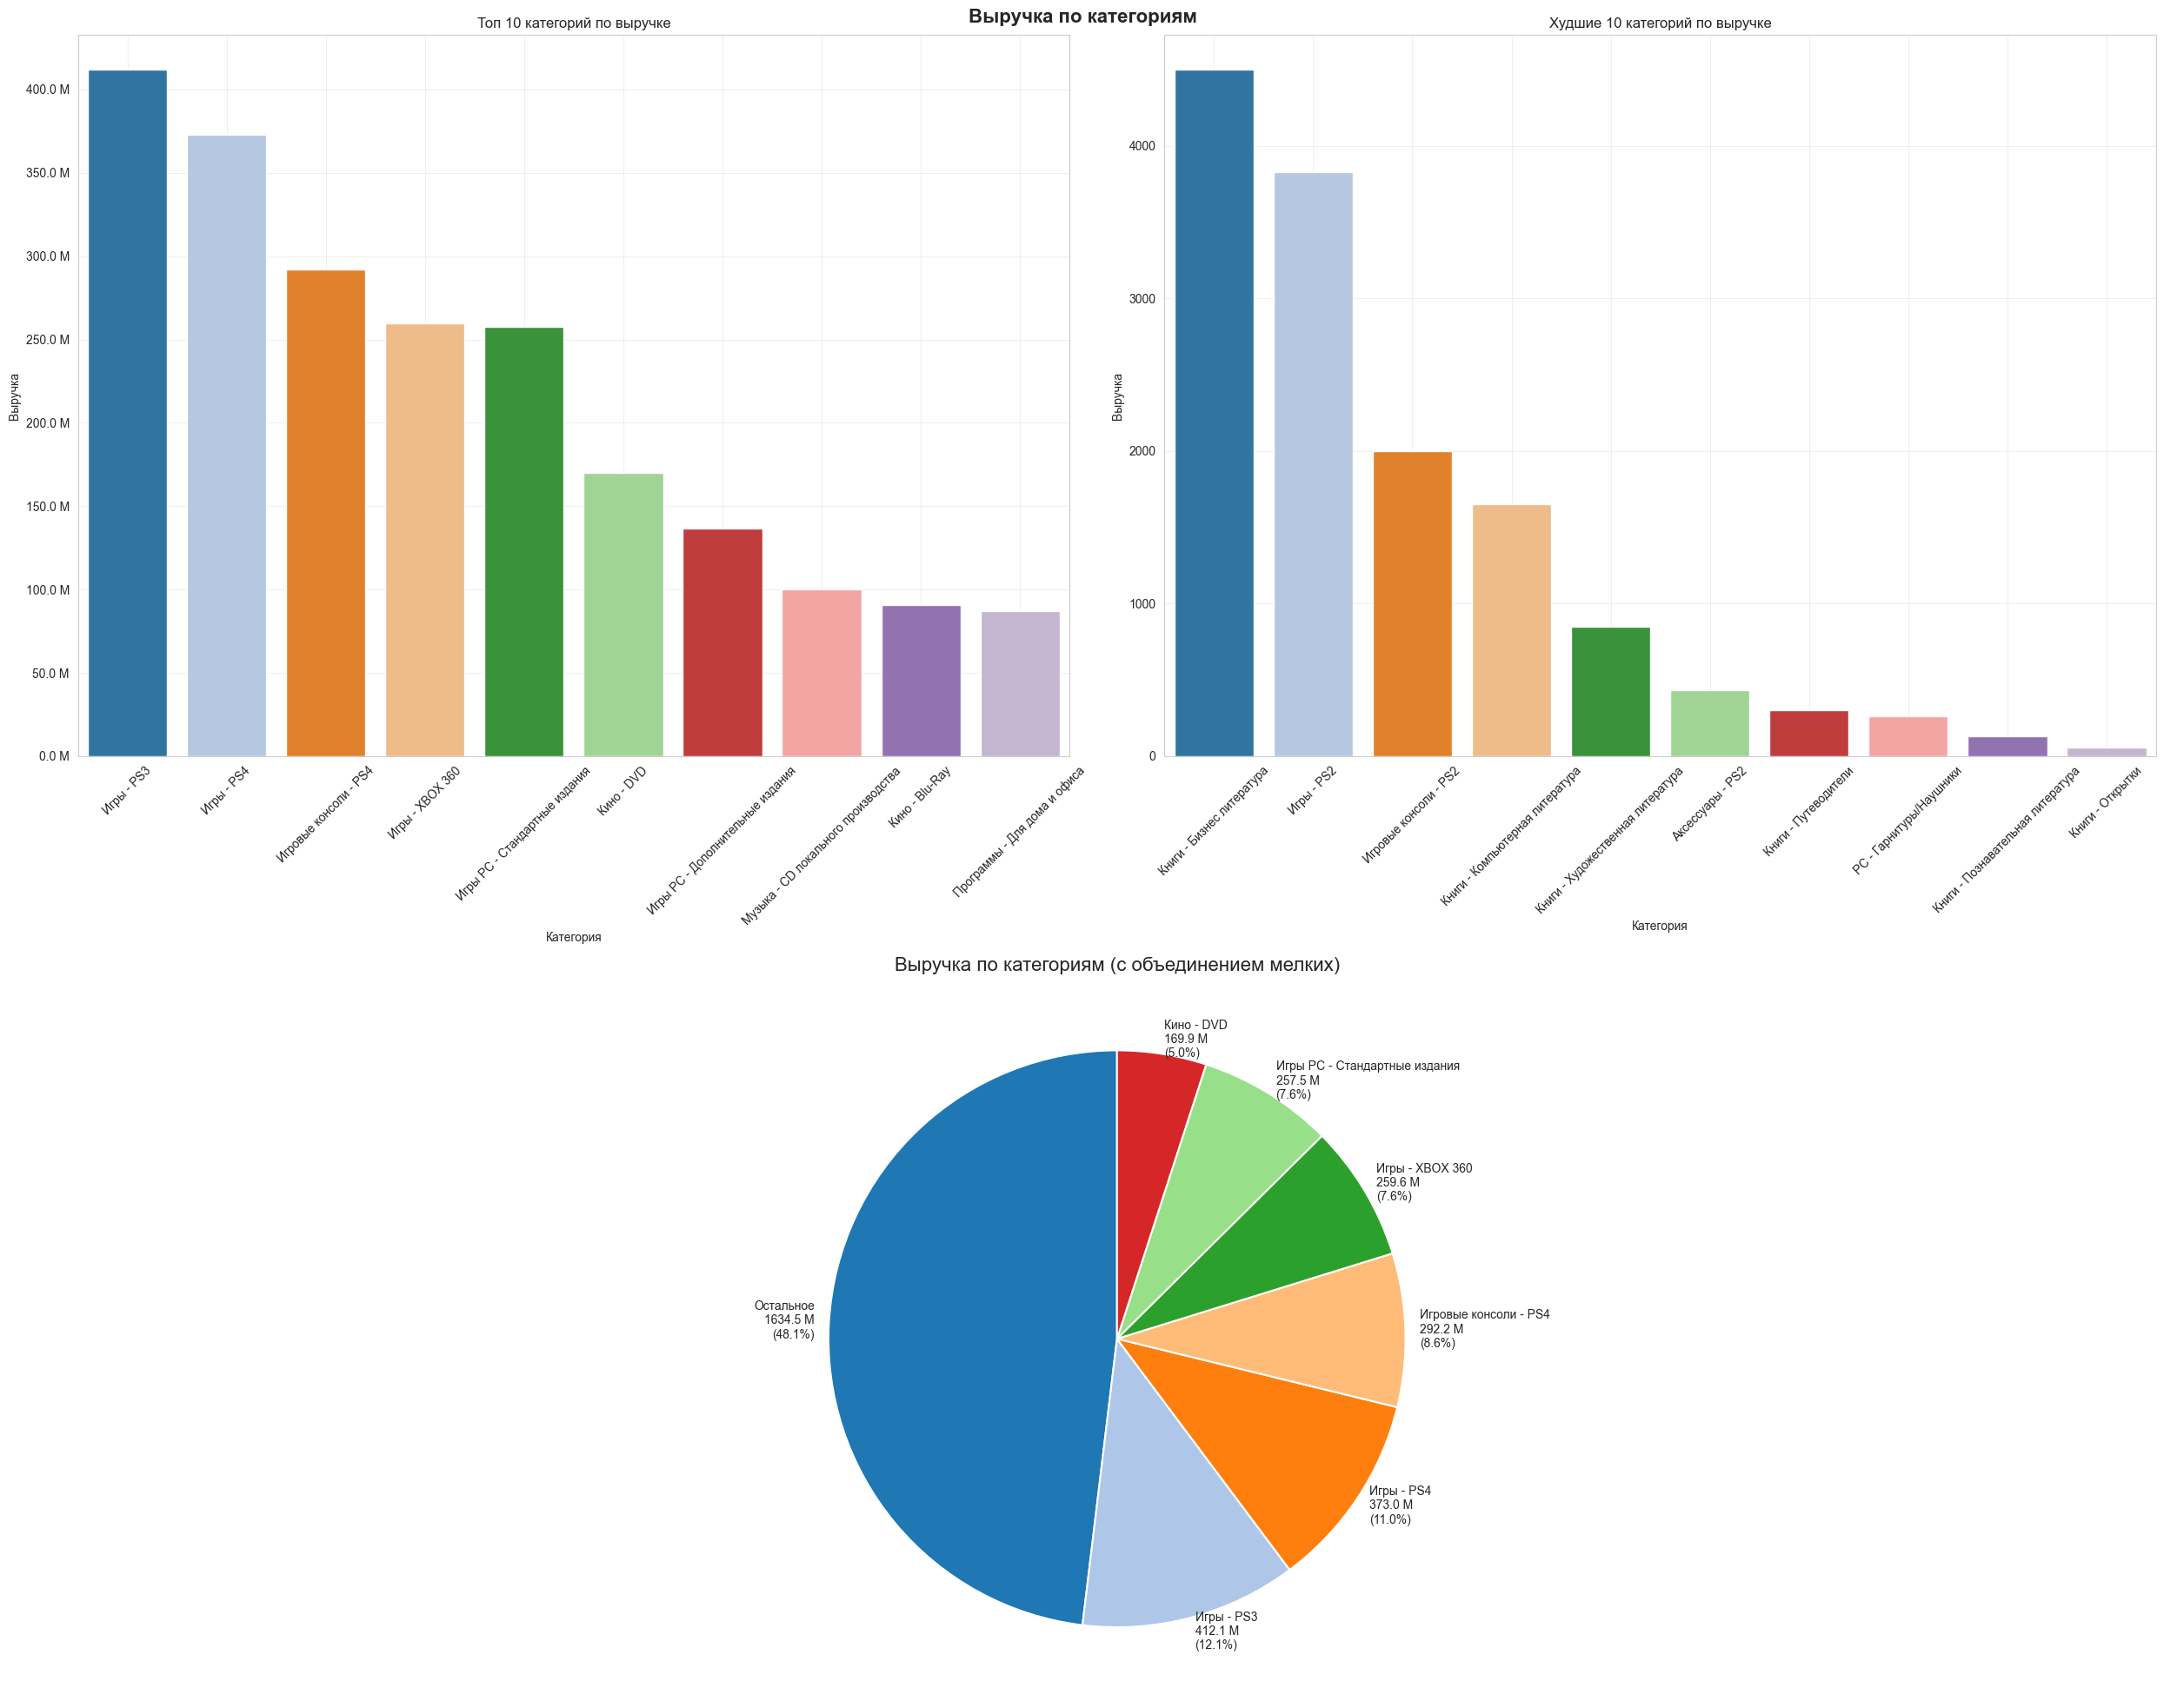

In [283]:
plot_graphs(full_sales_info, "item_category_name", "total_price", "Выручка по категориям", "revenue_by_categories", 10)

### Продажи по категориям

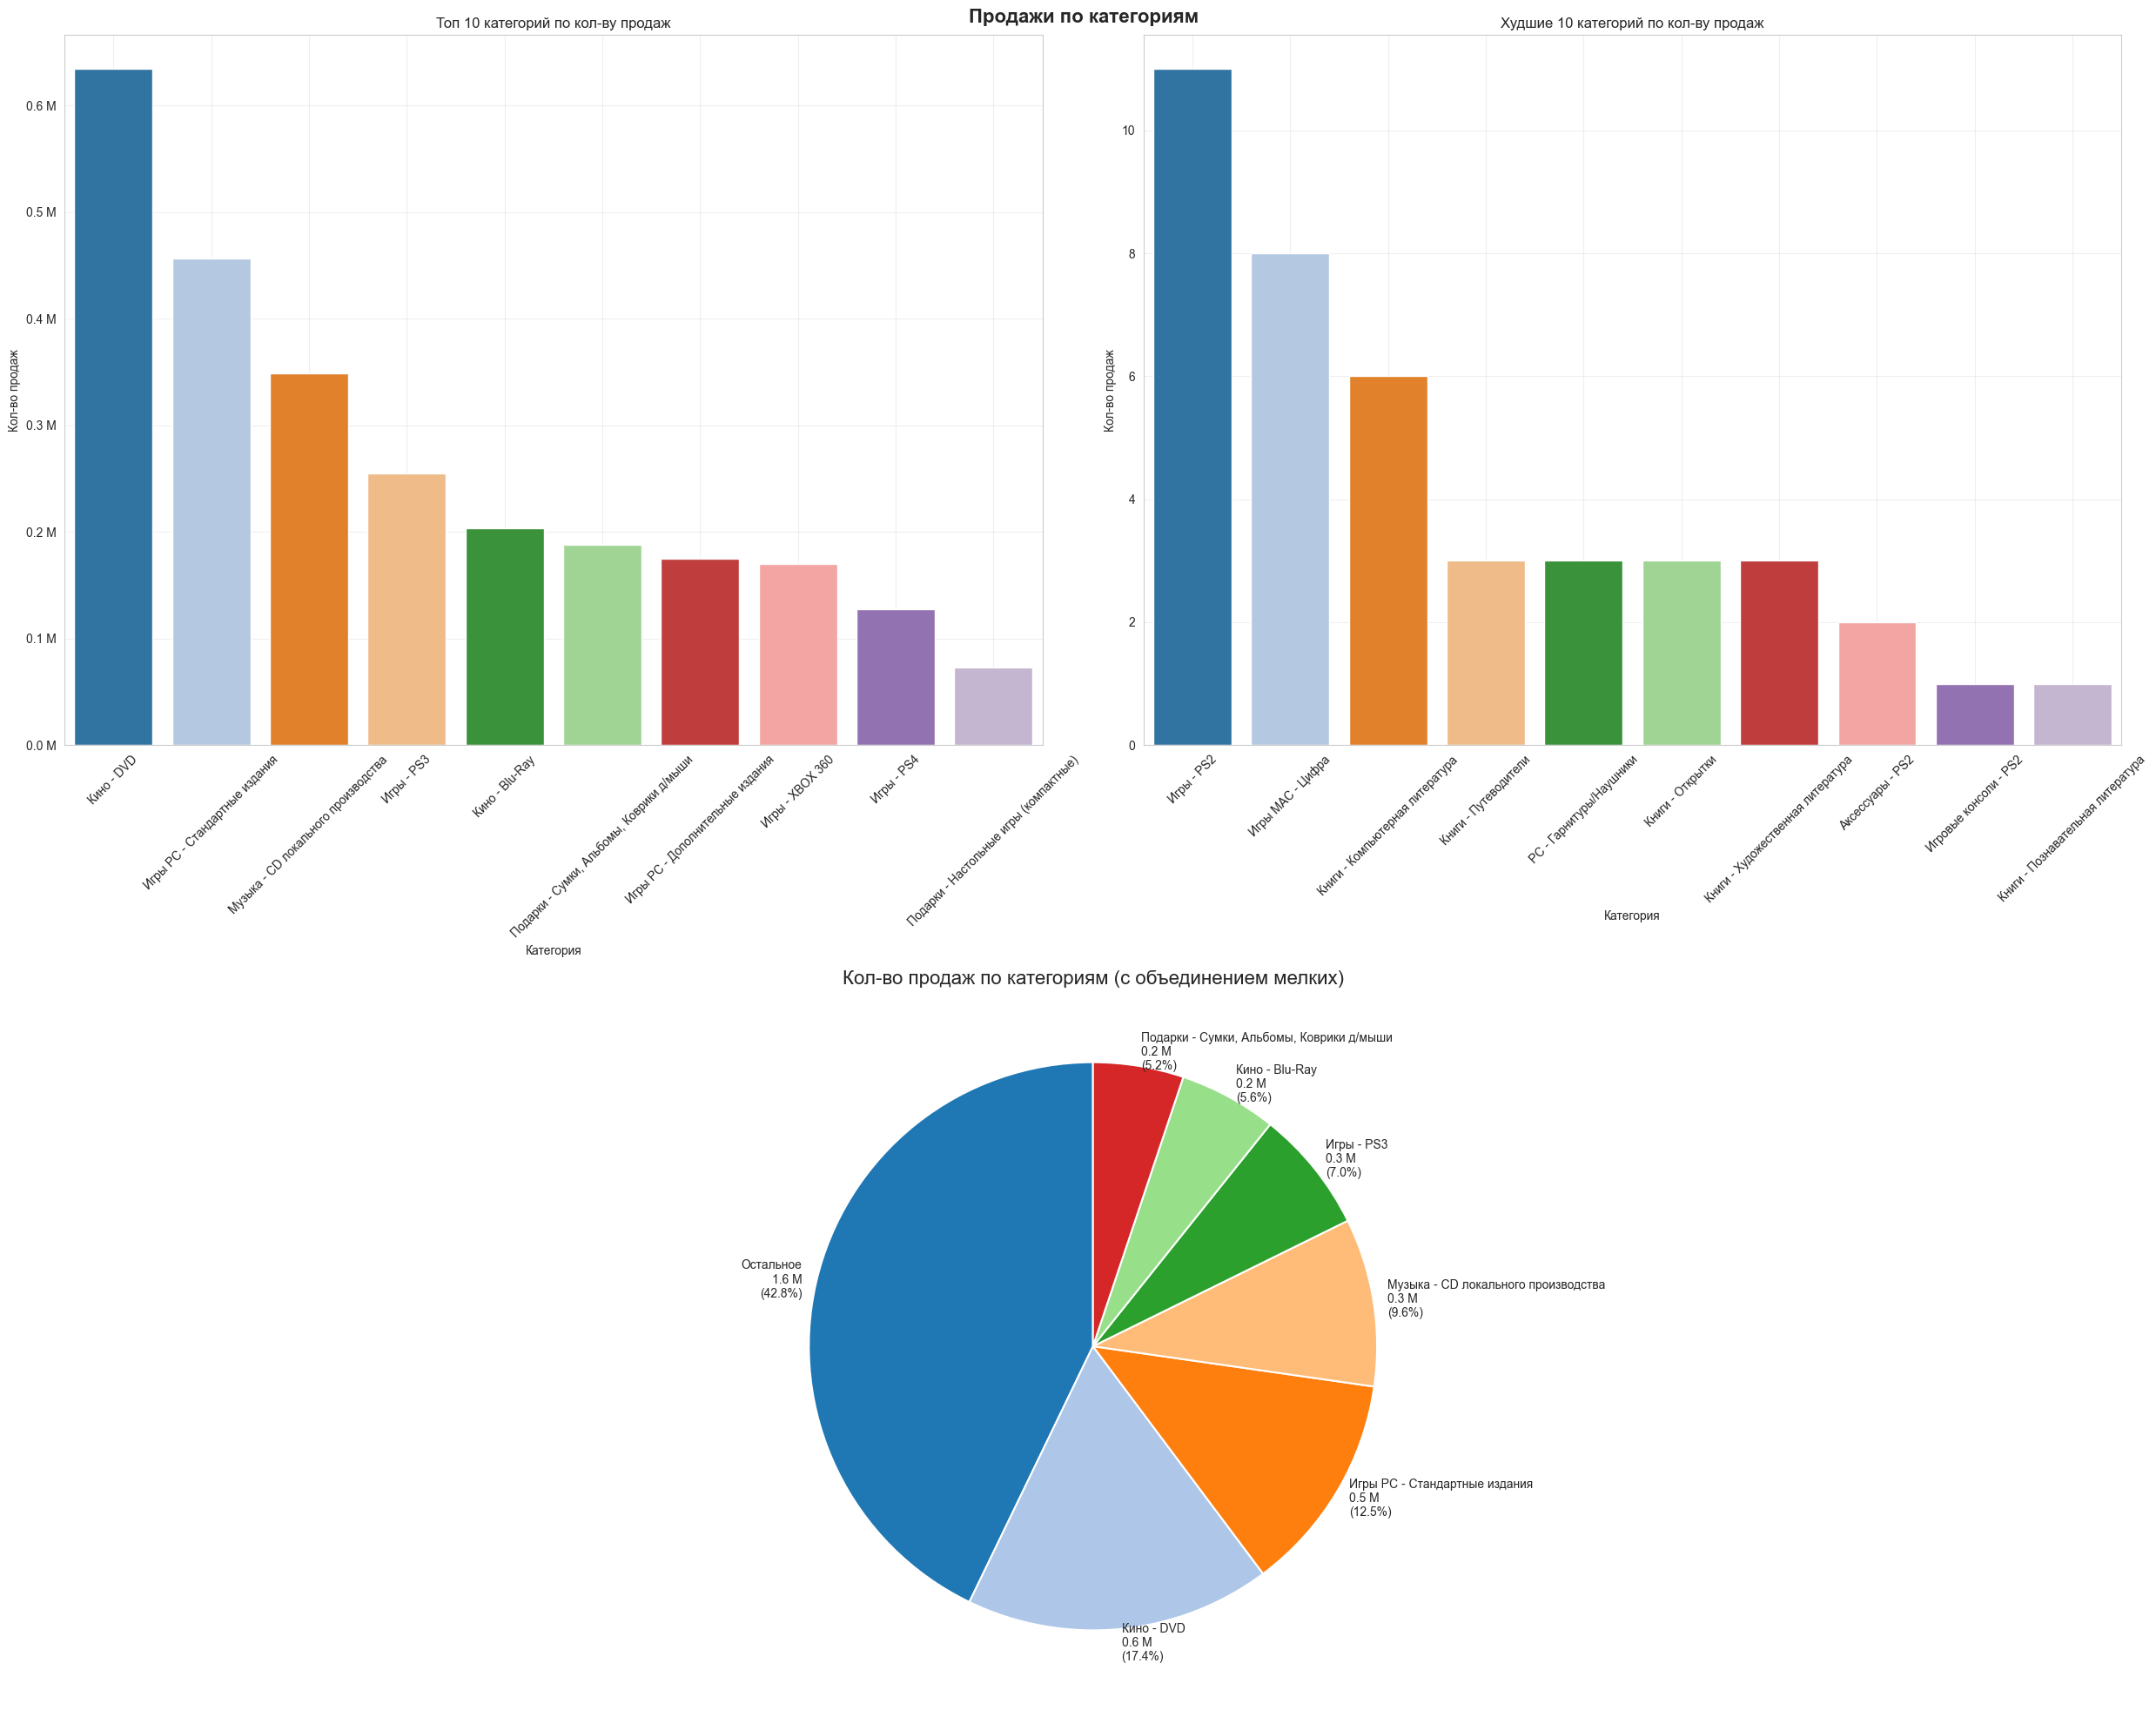

In [284]:
plot_graphs(full_sales_info, "item_category_name", "item_cnt_day", "Продажи по категориям", "sales_by_categories", 10)

### Выручка по товарам

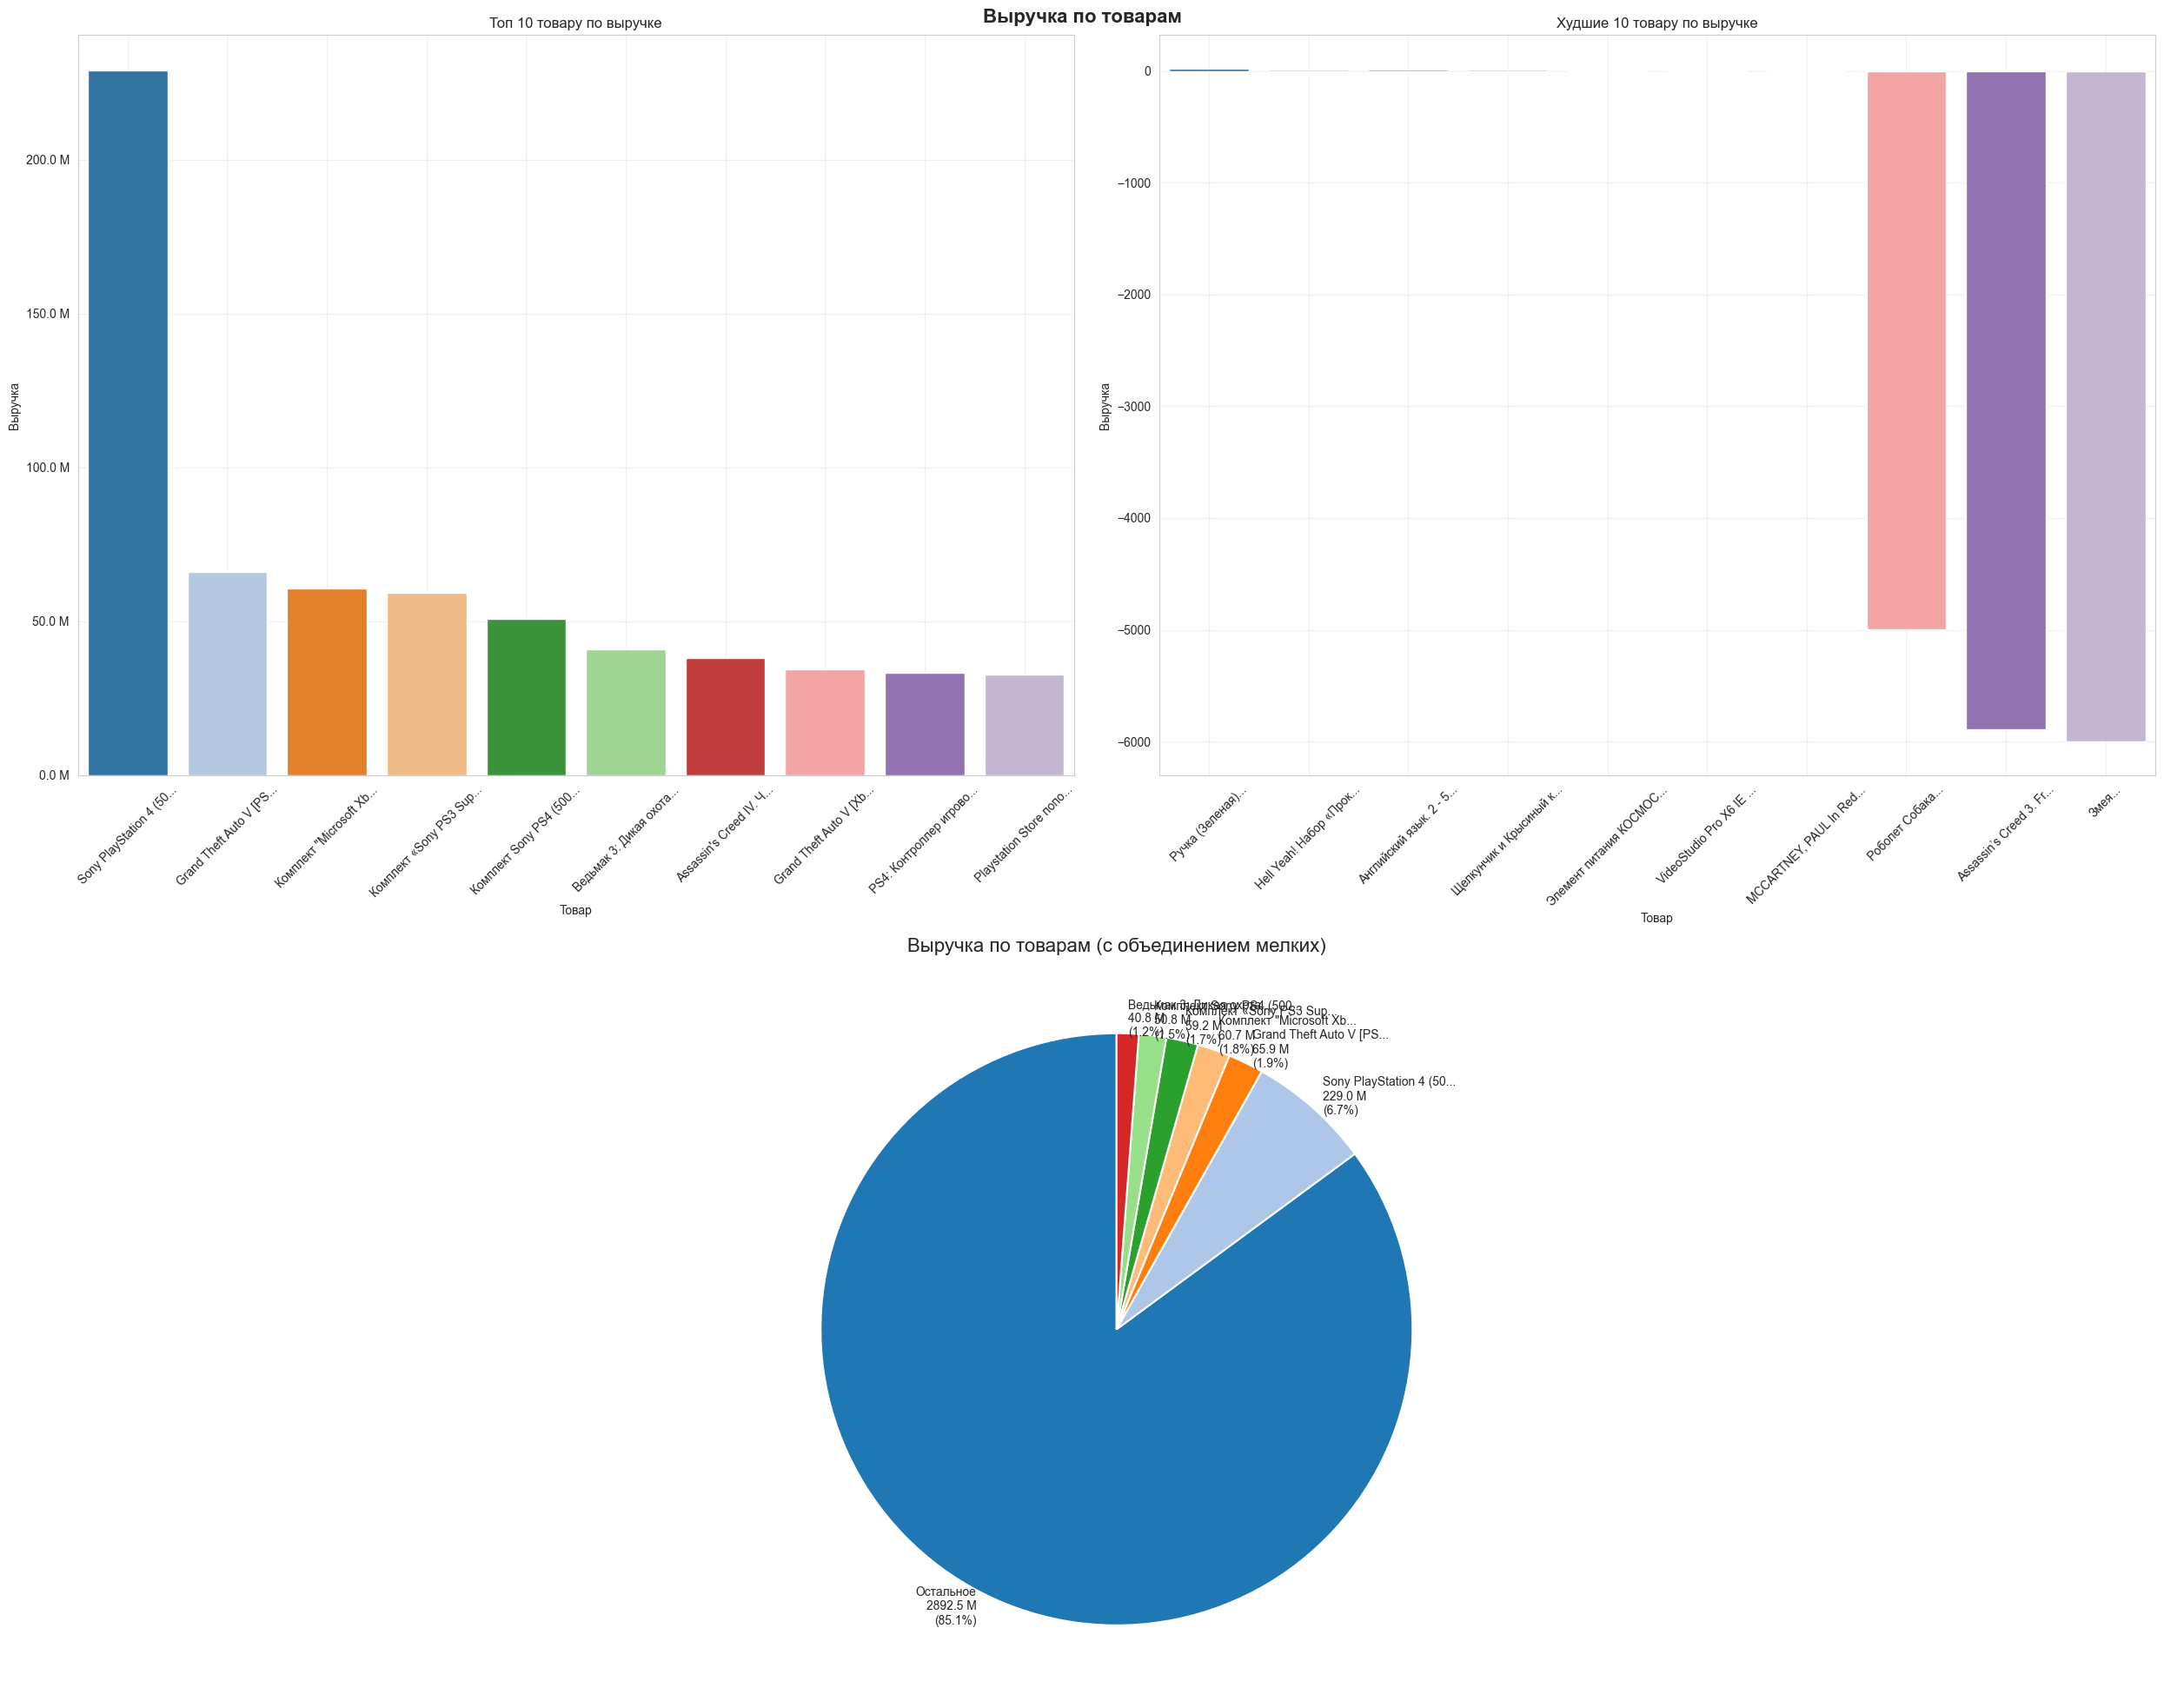

In [285]:
plot_graphs(full_sales_info, "short_item_name", "total_price", "Выручка по товарам", "revenue_by_items", 10)

### Выручка по магазинам

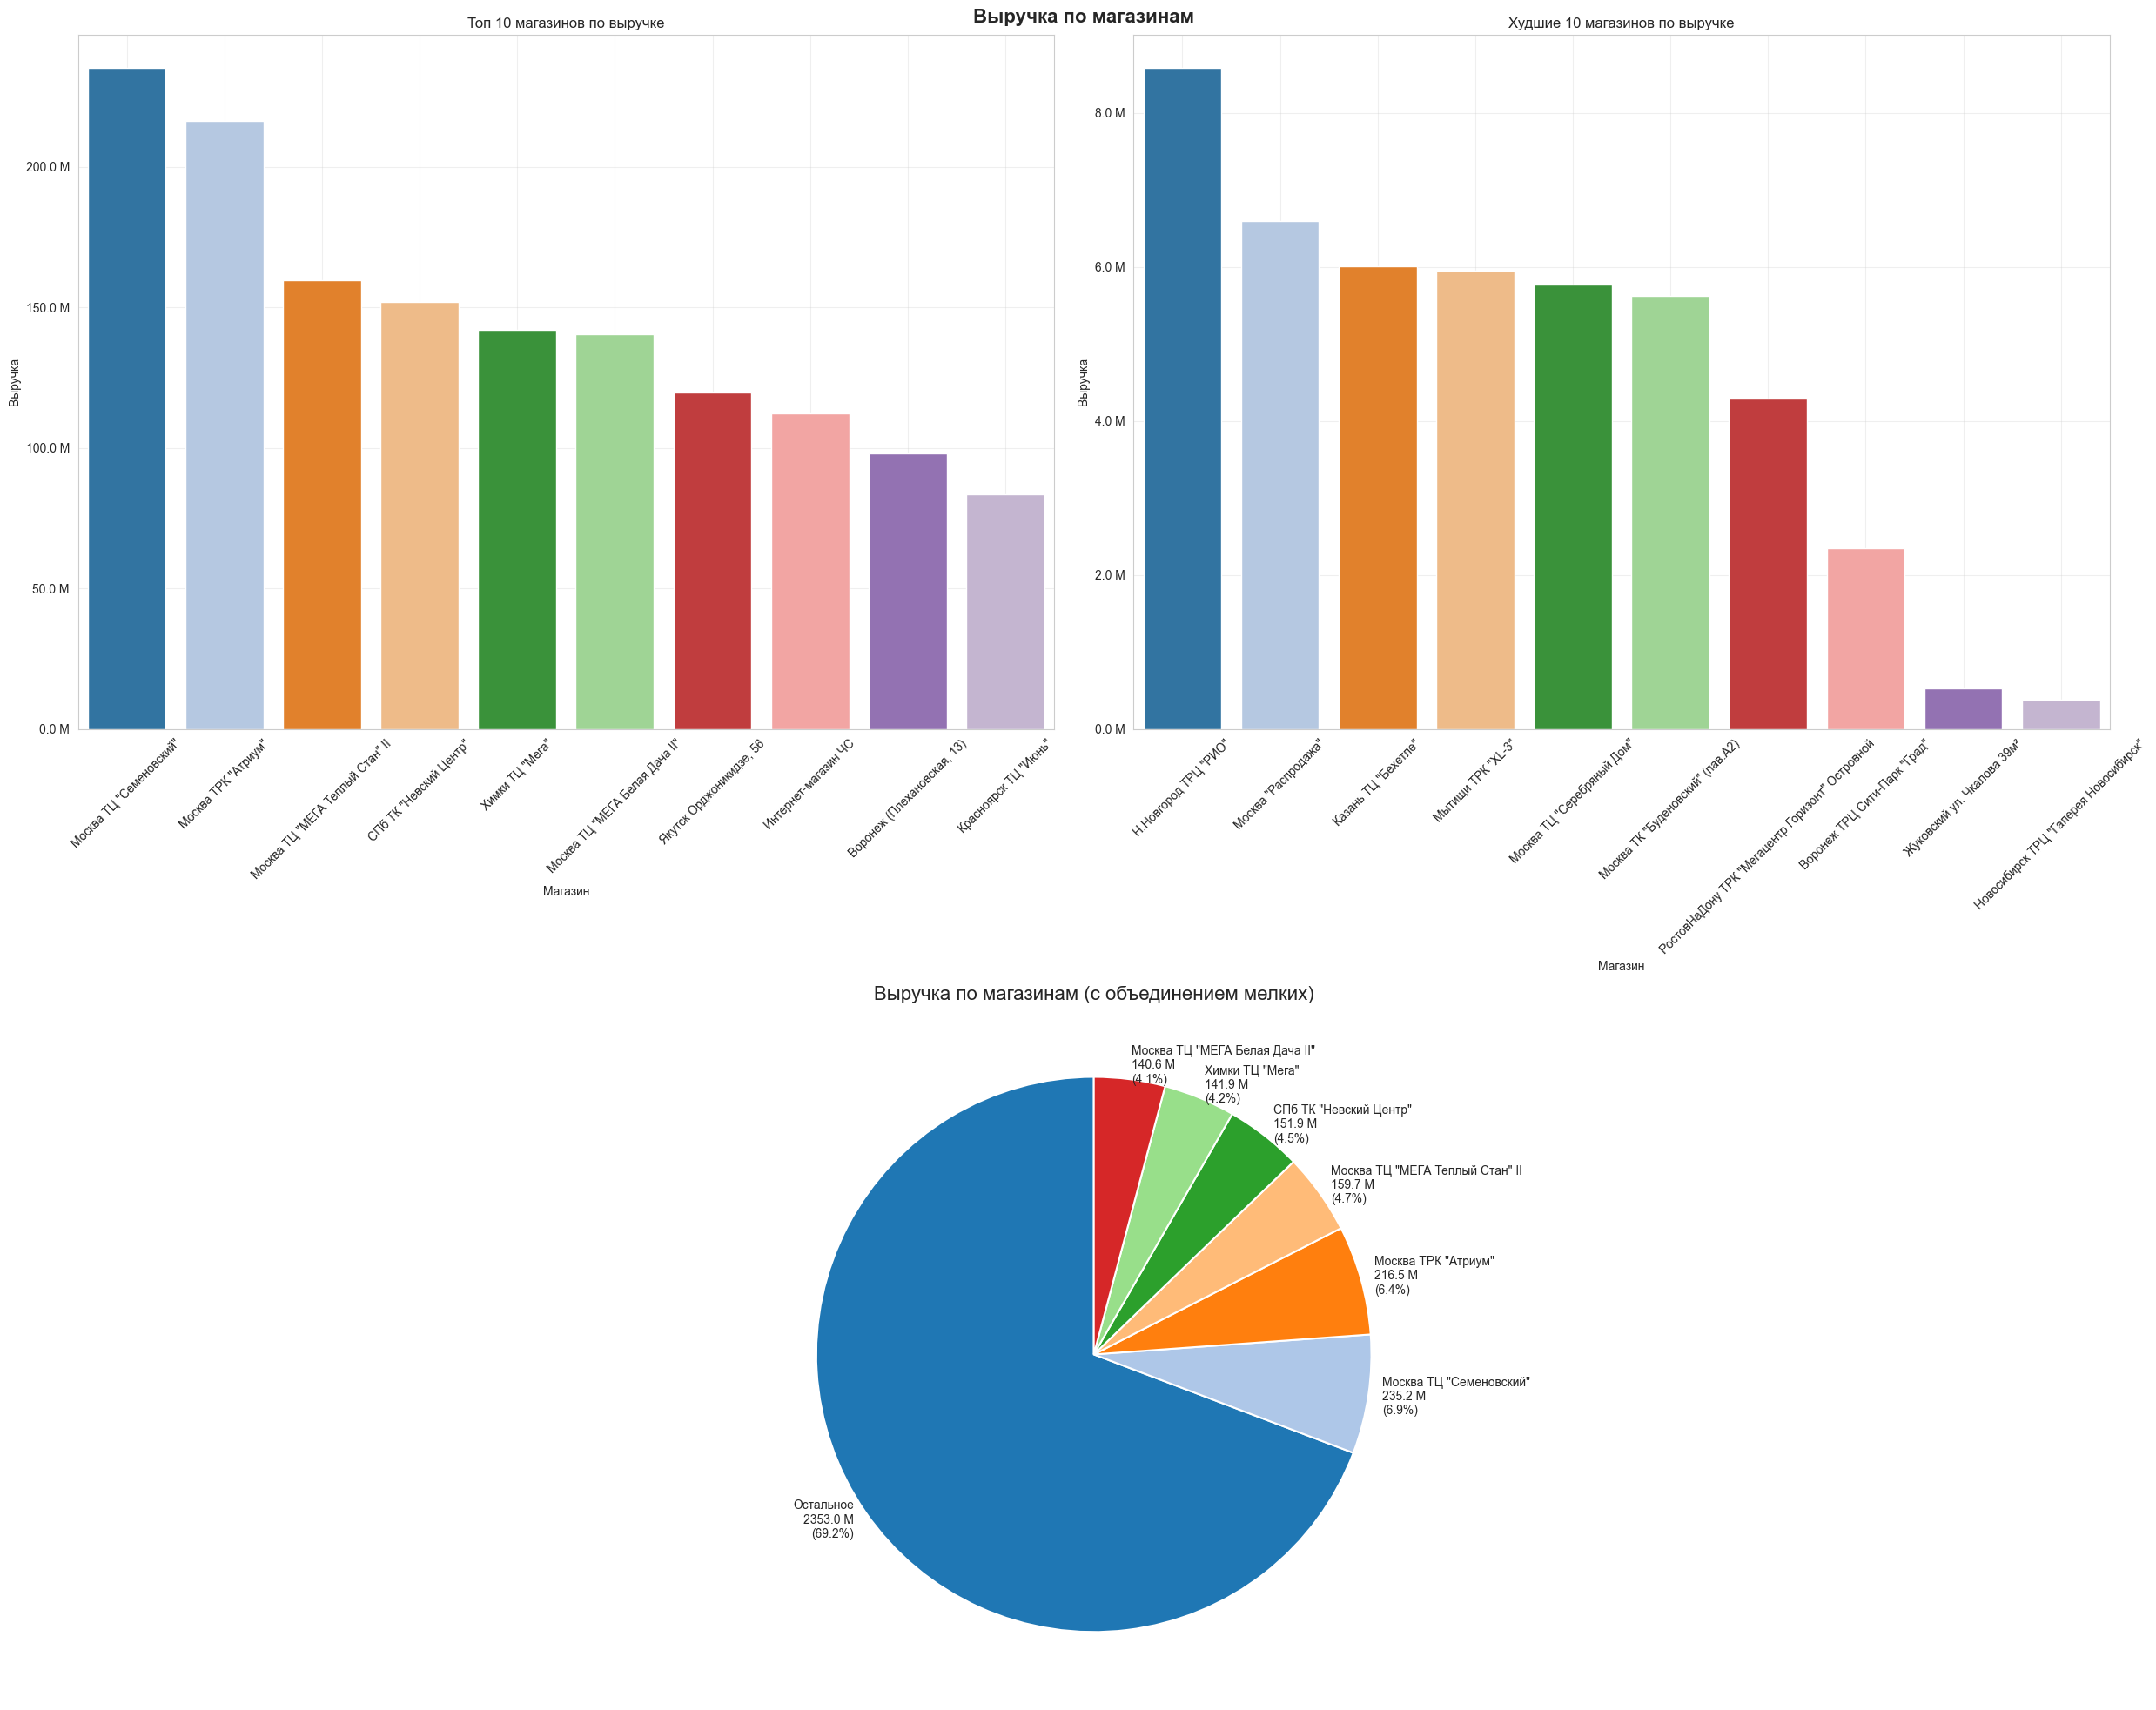

In [290]:
plot_graphs(full_sales_info, "shop_name", "total_price", "Выручка по магазинам", "revenue_by_shops", 10)

### Выручка по городам

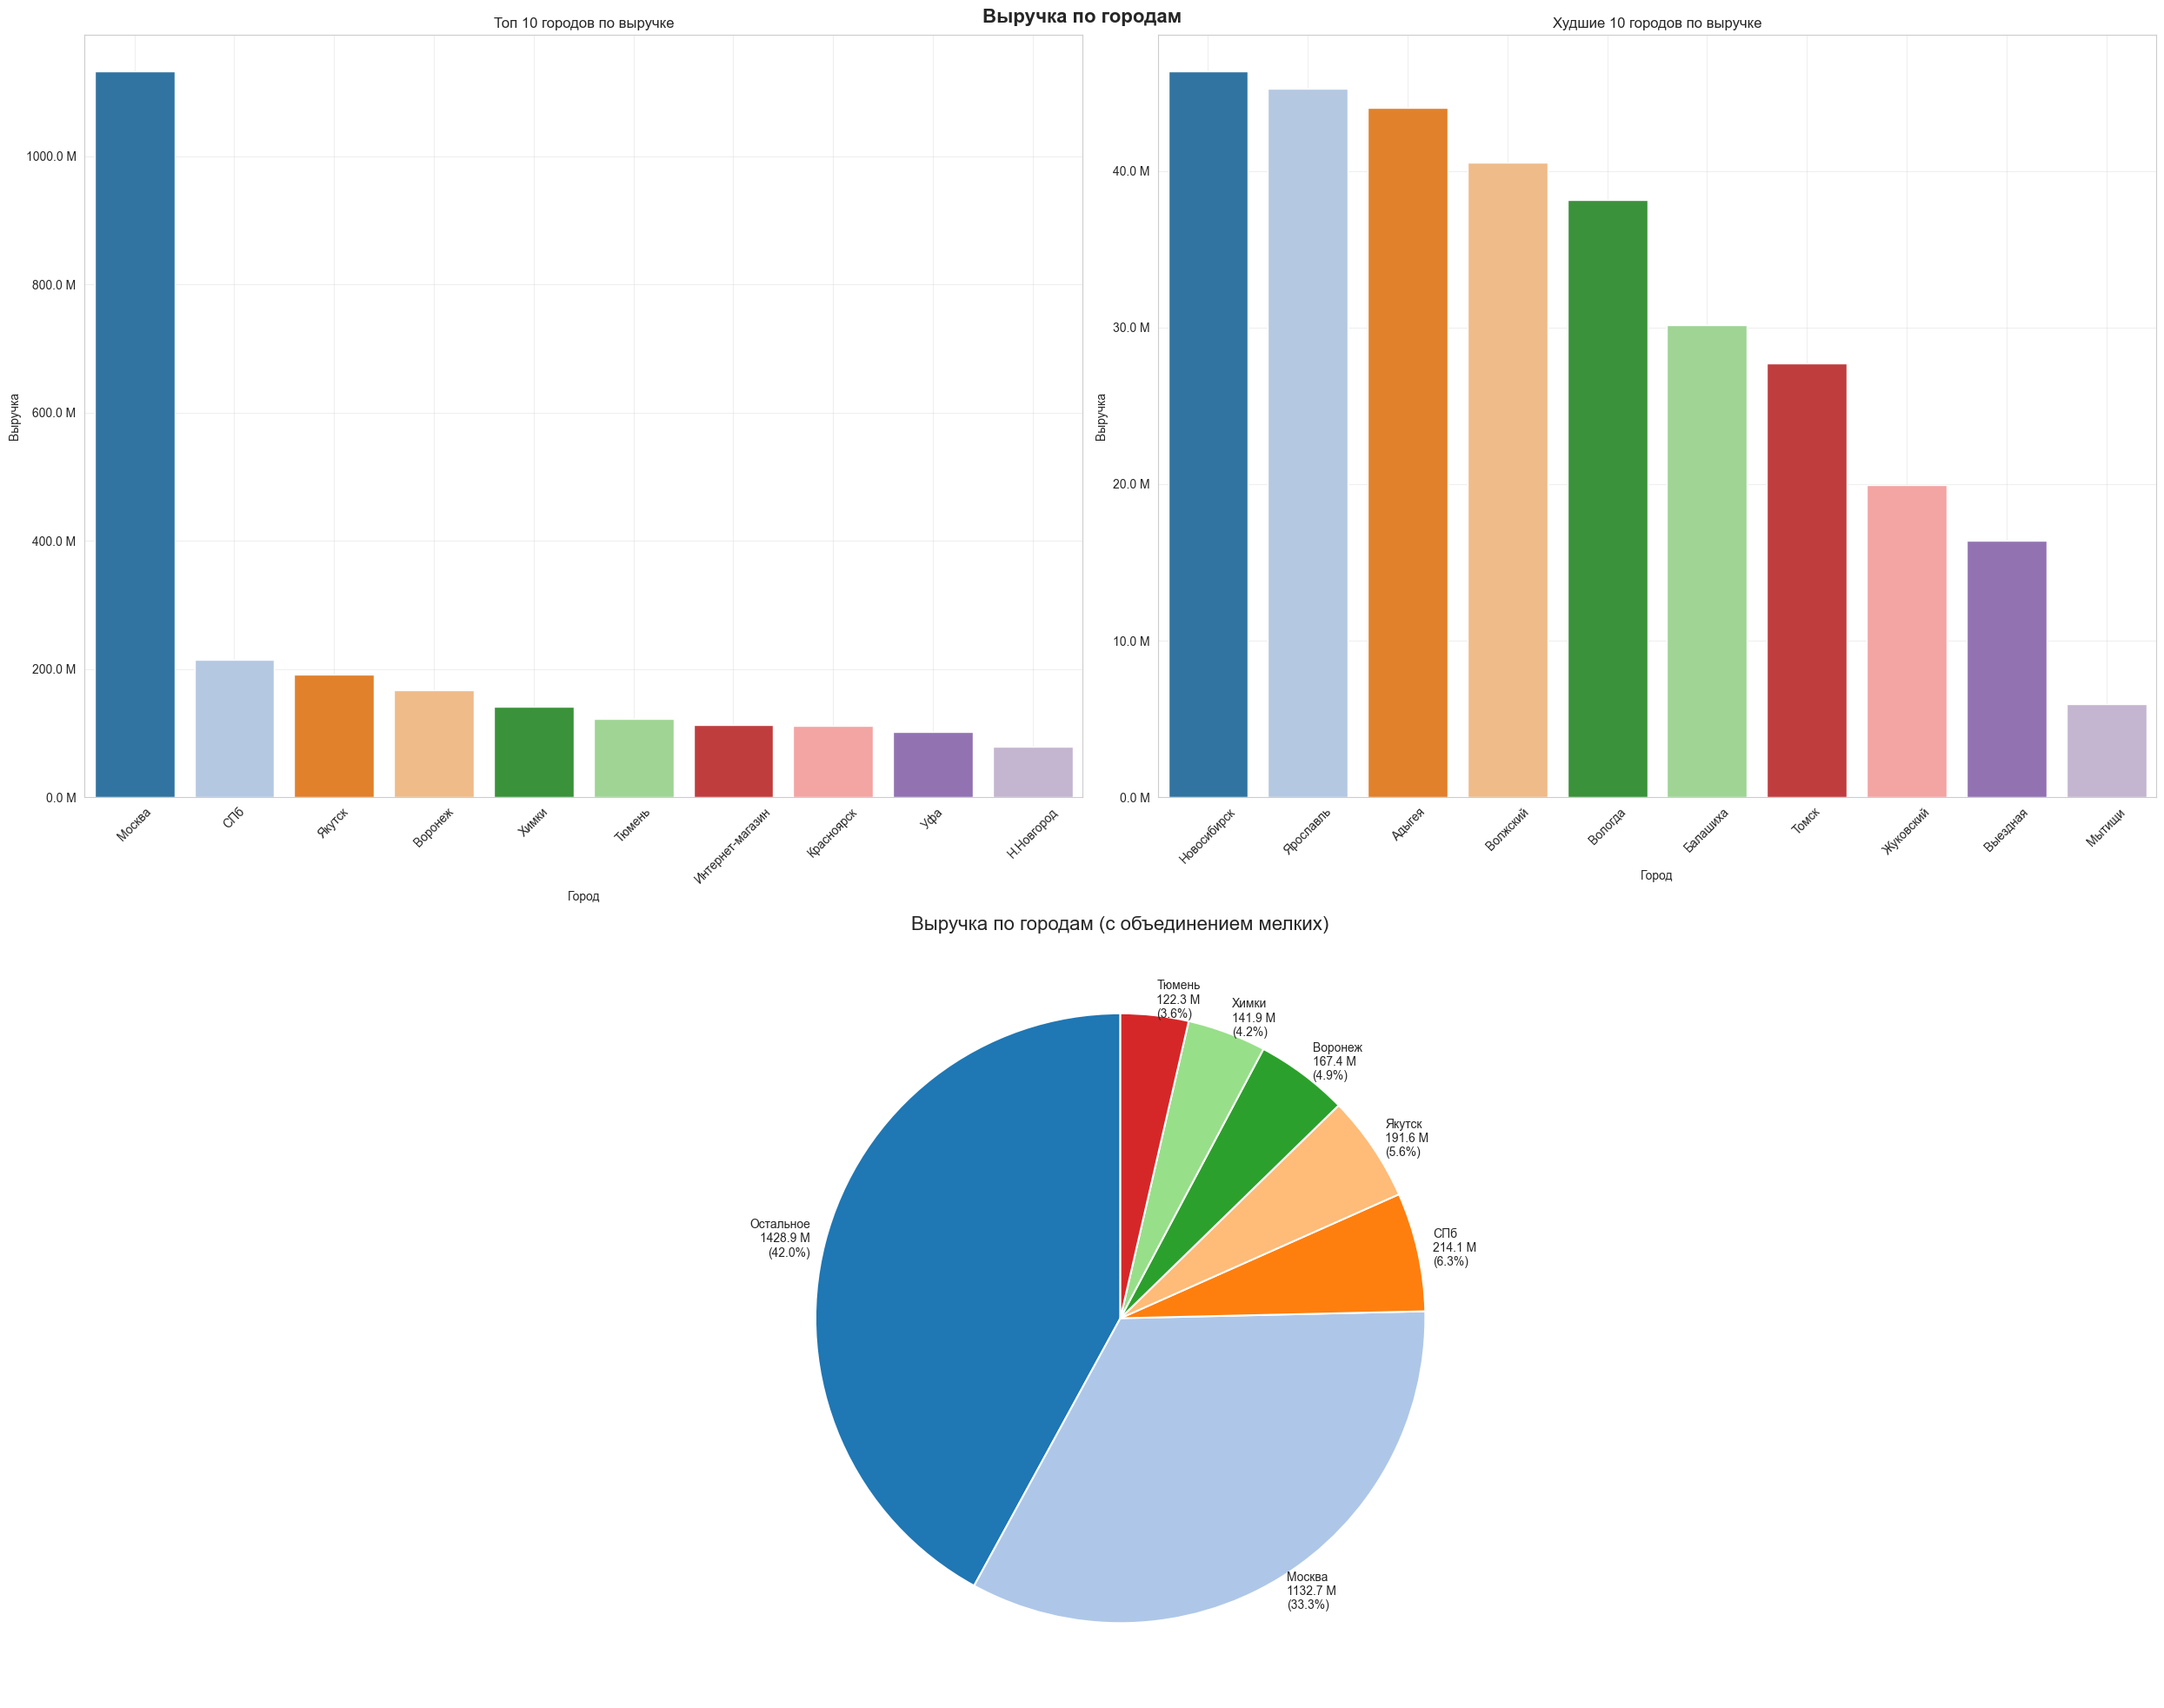

In [292]:
plot_graphs(full_sales_info, "city", "total_price", "Выручка по городам", "revenue_by_cities", 10)

### Продажи по месяцам

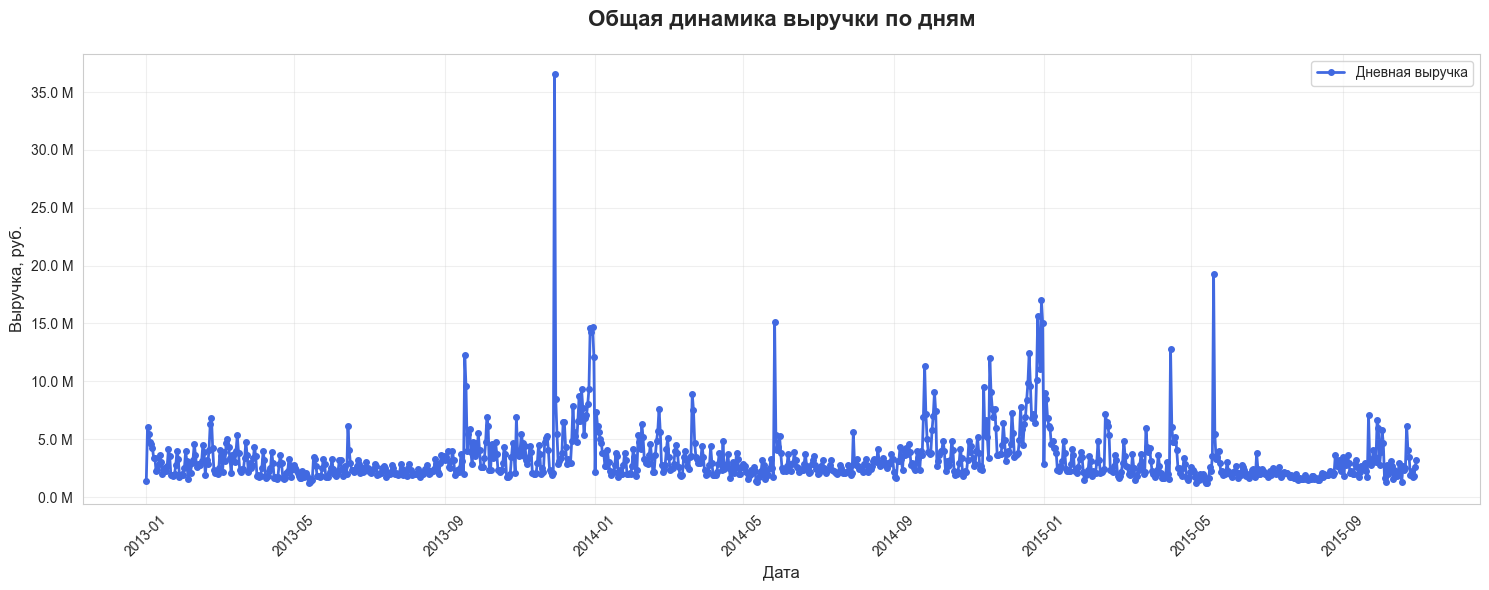

In [298]:
full_sales_info['date'] = pd.to_datetime(full_sales_info['date'], format='%d.%m.%Y')

daily_revenue = full_sales_info.groupby('date')['total_price'].sum().reset_index()

plt.figure(figsize=(15, 6))
sns.set_style("whitegrid")

plt.plot(daily_revenue['date'], daily_revenue['total_price'], 
         marker='o', markersize=4, linewidth=2, color='royalblue', label='Дневная выручка')

plt.gca().yaxis.set_major_formatter(FuncFormatter(millions_formatter))
plt.title('Общая динамика выручки по дням', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Выручка, руб.', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("artifacts/figures/eda/revenue_trend.png", dpi=300, bbox_inches='tight')
plt.show()

Для Москвы

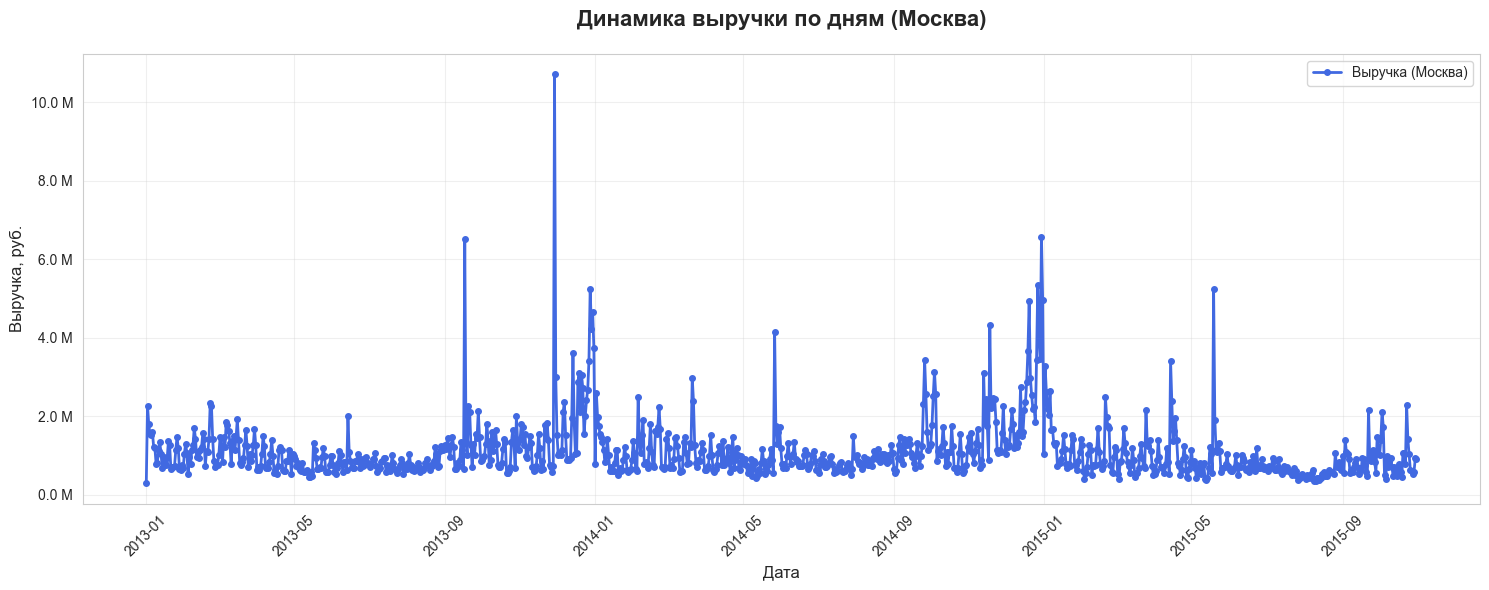

In [299]:
moscow_data = full_sales_info[full_sales_info['city'] == 'Москва'].copy()

moscow_data['date'] = pd.to_datetime(moscow_data['date'], format='%d.%m.%Y')

daily_revenue_moscow = moscow_data.groupby('date')['total_price'].sum().reset_index()

plt.figure(figsize=(15, 6))
sns.set_style("whitegrid")

plt.plot(daily_revenue_moscow['date'], daily_revenue_moscow['total_price'],
         marker='o', markersize=4, linewidth=2, color='royalblue', label='Выручка (Москва)')

plt.gca().yaxis.set_major_formatter(FuncFormatter(millions_formatter))
plt.title('Динамика выручки по дням (Москва)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Выручка, руб.', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("artifacts/figures/eda/revenue_trend_moscow.png", dpi=300, bbox_inches='tight')
plt.show()